In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import matplotlib.ticker
import matplotlib.pyplot as plt
from   matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
import matplotlib.patheffects as PathEffects
from   scipy.optimize import root

import seaborn as sb
import Simulation as sim
from   Simulation import dust_to_gas_DataParticles

import scaling as sc
import scipy.signal as scisig
sb.set(context = 'notebook',font = 'serif',font_scale = 1.3)
sb.set_palette('Set2', 8)



d2g = sim.dust_to_gas_DataParticles

def radius(x,y):
    return np.sqrt(x*x + y*y)

def cm_to_microns(s):
    return s*1e4 # microns/cm

def CreateDir(path):
    try                    : os.mkdir(path)
    except FileExistsError : pass

def cartisian_to_polar_velocity(x,y,r,vx,vy):
    """
    Transforms cartesian velocity coordiantes to
    polar coordiantes in a x-y plane.
    
    r can be calulated with radius function
    """
    vr   = (x*vx + y*vy)/r
    vphi = (x*vy - vx*y)/r 
    return vr, vphi
    
cm_to_microns(1) == 10000
#%matplotlib widget

True

In [ ]:
sphere = sim.DataSphere   ('../run_extracted/run006/', units = sc.CGS)
print("%.2e"%(sphere.t[-1]/sc.CGS.yr))

In [ ]:
sphere.t

## Libaray Docstring

In [ ]:
help(sim)

## Data Sphere Docstring

In [ ]:
help(sim.DataSphere)

## DataParticles Docstring

In [ ]:
help(sim.DataParticles)

### To add common x or y labels

In [ ]:
# fig.add_subplot(111, frameon=False)
## hide tick and tick label of the big axis
# plt.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)

# D2G Plots

In [ ]:
def radius(x,y):
    return np.sqrt(x*x + y*y)

In [ ]:
def cm_to_microns(s):
    return s*1e4 # microns/cm

In [ ]:
cm_to_microns(1) == 10000

In [ ]:
sphere = sim.DataSphere   ('../run_extracted/run067/', units = sc.CGS)
sphere._vg[:,:-1] = (sphere._rc[:,1:]-sphere._rc[:,:-1])/sphere.dt[None,:-1]
sphere.update()

In [ ]:
path      = '../SimData/Both_Grains_4_pr_5bins_1000_0.5kep/'#
figpath   = '../plots/'
jointpath = figpath + path[11:-1]+'/'
try                   : os.mkdir(jointpath)
except FileExistsError: pass

rowrange = { 'skiprows' : 0,    # Start
             'max_rows' : None } # \# Lines to read after start
p        = sim.DataParticles(path, sphere, **rowrange)
s_unique = np.unique(p.s[0])
print('unqiue species: \t',len(s_unique))
print('Snapshots loaded:\t',p.r[:,0].size)



In [ ]:
x   = np.loadtxt(path + 'x.txt'    ,**rowrange)
y   = np.loadtxt(path + 'y.txt'    ,**rowrange)
vx  = np.loadtxt(path + 'vx.txt'   ,**rowrange)
vy  = np.loadtxt(path + 'vy.txt'   ,**rowrange)
tm  = np.loadtxt(path + 'time.txt' ,**rowrange)
st  = np.loadtxt(path + 'St.txt'   ,**rowrange)
r   = radius(x,y)

In [ ]:
#####
ids    = 2 # in unique
idcell = 3000 # which bin do i want, in first snap
idp    = 3 # which of the # of same particles do i want
#####


bins = p.search(p.r[0])
mask = (bins == idcell) & (p.s[0] == s_unique[ids] )
s    = p.s[0,mask][idp] #s_unique[ids]

fig, ((axy, ax, ay),(ar, avx, avy), (ast, axst, ayst) ) = plt.subplots(3,3, figsize = (15,15))

axy.plot( x[:,mask][:,idp]/sc.CGS.AU,  y[:,mask][:,idp]/sc.CGS.AU)
ax .plot(tm[:,mask][:,idp]/sc.CGS.yr,  x[:,mask][:,idp]/sc.CGS.AU)
ay .plot(tm[:,mask][:,idp]/sc.CGS.yr,  y[:,mask][:,idp]/sc.CGS.AU)
ar .plot(tm[:,mask][:,idp]/sc.CGS.yr,  r[:,mask][:,idp]/sc.CGS.AU)
avx.plot(tm[:,mask][:,idp]/sc.CGS.yr, vx[:,mask][:,idp])
avy.plot(tm[:,mask][:,idp]/sc.CGS.yr, vy[:,mask][:,idp])

ast .plot(tm[:,mask][:,idp]/sc.CGS.yr,  st[:,mask][:,idp])
axst.plot( x[:,mask][:,idp]/sc.CGS.AU,  st[:,mask][:,idp])
ayst.plot( y[:,mask][:,idp]/sc.CGS.AU,  st[:,mask][:,idp])


# tff  = np.sqrt(3*np.pi/(32*self.units.G*self.env.rho(rmag))) 
ax_s = ax.twiny()
tff  = np.sqrt(3*np.pi/(32 * sc.CGS.G * sphere.rho(sphere.rc[0])))

ax_s.plot(tm[:,mask][:,idp]/tff,  x[:,mask][:,idp]/sc.CGS.AU)
ax_s.grid(False)


#axy.set_xscale('log')
#axy.set_yscale('log')

ax .set_title('S = %.7s microns'%(cm_to_microns(s)))
axy.set_xlabel('x [AU]'     )
axy.set_ylabel('y [AU]'     )
ax .set_xlabel('time [yr]'  )
ax .set_ylabel('x [AU]'     )
ay .set_xlabel('time [yr]'  )
ay .set_ylabel('y [AU]'     )
ar .set_ylabel('radius [AU]')
ar .set_xlabel('time [yr]'  )
avx.set_ylabel('vx [cm/s]'  )
avx.set_xlabel('time [yr]'  )
avy.set_ylabel('vy [cm/s]'  )
avy.set_xlabel('time [yr]'  )

ast .set_xlabel('time [yr]'               )
ast .set_ylabel('Stokes number [Unitless]')
axst.set_xlabel('x coordiante [AU]'       )
axst.set_ylabel('Stokes number [Unitless]')
ayst.set_xlabel('y coordiante [AU]'       )
ayst.set_ylabel('Stokes number [Unitless]')


fig.tight_layout()
fig.savefig(jointpath + 'Spacial %.2e microns, cell %i, paricle %i'%(s,idcell,idp) +'.png')

In [ ]:
#####
ids    = 2 # in unique
idcell = 3000 # which bin do i want, in first snap
idp    = 3 # which of the # of same particles do i want
#####


bins = p.search(p.r[0])
mask = (bins == idcell) & (p.s[0] == s_unique[ids] )
s    = p.s[0,mask][idp] #s_unique[ids]

fig, ((axy, ax, ay),(ar, avx, avy), (ast, axst, ayst) ) = plt.subplots(3,3, figsize = (15,15))

axy.plot( x[:,mask][:,idp]/sc.CGS.AU,  y[:,mask][:,idp]/sc.CGS.AU)
ax .plot(tm[:,mask][:,idp]/sc.CGS.yr,  x[:,mask][:,idp]/sc.CGS.AU)
ay .plot(tm[:,mask][:,idp]/sc.CGS.yr,  y[:,mask][:,idp]/sc.CGS.AU)
ar .plot(tm[:,mask][:,idp]/sc.CGS.yr,  r[:,mask][:,idp]/sc.CGS.AU)
avx.plot(tm[:,mask][:,idp]/sc.CGS.yr, vx[:,mask][:,idp])
avy.plot(tm[:,mask][:,idp]/sc.CGS.yr, vy[:,mask][:,idp])

ast .plot(tm[:,mask][:,idp]/sc.CGS.yr,  st[:,mask][:,idp])
axst.plot( x[:,mask][:,idp]/sc.CGS.AU,  st[:,mask][:,idp])
ayst.plot( y[:,mask][:,idp]/sc.CGS.AU,  st[:,mask][:,idp])


# tff  = np.sqrt(3*np.pi/(32*self.units.G*self.env.rho(rmag))) 
#ax_s  = ax.twiny()
tff     = np.sqrt(3*np.pi/(32 * sc.CGS.G * sphere.rho(sphere.rc[0])))
Ftff    = lambda x: x*sc.CGS.yr/tff
Ftffinv = lambda x: x*tff/sc.CGS.yr
ax_s = ax.secondary_xaxis('top', functions=(Ftff,Ftffinv))


#ax_s.plot(tm[:,mask][:,idp],  x[:,mask][:,idp]/sc.CGS.AU)
#ax_s.grid(False)


#axy.set_xscale('log')
#axy.set_yscale('log')

ax .set_title('S = %.7s microns'%(cm_to_microns(s)))
axy.set_xlabel('x [AU]'     )
axy.set_ylabel('y [AU]'     )
ax .set_xlabel('time [yr]'  )
ax .set_ylabel('x [AU]'     )
ay .set_xlabel('time [yr]'  )
ay .set_ylabel('y [AU]'     )
ar .set_ylabel('radius [AU]')
ar .set_xlabel('time [yr]'  )
avx.set_ylabel('vx [cm/s]'  )
avx.set_xlabel('time [yr]'  )
avy.set_ylabel('vy [cm/s]'  )
avy.set_xlabel('time [yr]'  )

ast .set_xlabel('time [yr]'               )
ast .set_ylabel('Stokes number [Unitless]')
axst.set_xlabel('x coordiante [AU]'       )
axst.set_ylabel('Stokes number [Unitless]')
ayst.set_xlabel('y coordiante [AU]'       )
ayst.set_ylabel('Stokes number [Unitless]')


fig.tight_layout()
fig.savefig(jointpath + 'Spacial %.2e microns, cell %i, paricle %i'%(s,idcell,idp) +'.png')

In [ ]:
x.shape

In [ ]:
sphere.idstep = 0

In [ ]:
tff/p.units.yr

In [ ]:
print(len(s_unique))

In [ ]:
sphere.t.shape

In [ ]:
second_core

In [ ]:
b,a = scisig.butter(2, 0.01) # filter 0.01
I,J = 7,1
fig = plt.figure(figsize = (14,I*4))
#ax  = plt.subplot(I,J,1)
ii  = 0
s   = s_unique[-1]



insnap = 0
norm = []
sphere.idstep = 0
second_core = np.argmax(sphere._T[0,:]>7000) # at center
tff  = np.sqrt(3*np.pi/(32 * sc.CGS.G * sphere.rho(sphere.rc[0])))
for idx, insnap in enumerate(np.arange(0,324,53) , 1):
#for idx, insnap in enumerate([0,1,5, 75 ,226, 324] , 1):

#for idx, insnap in enumerate(np.arange(0,15,3) , 1):
    ax       = plt.subplot(I,J,idx)
    ax1      = ax.twinx()
    sphere.idstep = insnap
    for ids,s in enumerate(s_unique):
        D        = d2g(p,s, insnap)
        dust_gas = D[0]#scisig.filtfilt(b,a, D[0]) 
        #dust_gas = scisig.wiener(D[0], 20)
        #dust_gas = scisig.filtfilt(b,a, D[0])
        if insnap == 0:
            norm.append(dust_gas[:-1].max()) # Normed after the initial d2g ratio
            #norm     =  #dust_gas[:-1].max()
        ax.plot(sphere._rc[:-2,insnap]/p.units.AU, dust_gas[:-1]/norm[ids], 
                label = 's        = %.2e Microns\nnorm = %.2e'%(cm_to_microns(s), norm[ids]))
        
    ax1.plot(sphere._rc[:-2,insnap]/p.units.AU, sphere._rho[:-2,insnap])
    ax1.set_yscale('log')
    
    #ax.set_yscale('log')

    ax.set_yscale('log')
    ax.set_ylim([1e-2,1e6])
    
    ax.set_title('snap: %i at t = %.2f tff, time to second core = %.2e' \
                 %(insnap, sphere.t[insnap]/tff,(sphere.t[insnap]-sphere.t[second_core] )/sc.CGS.yr ))
    ax.set_xlabel('Radius [AU]')
    ax.set_ylabel('Dust to gas ratio [Unitless]\nnormed with maximum values')
    #ax.ticklabel_format(useOffset=False)
    ax.set_xscale('log')   
    #ax.set_yscale('log')   
    ax.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left', borderaxespad = 0.)

    
fig.tight_layout()
#fig.savefig(jointpath + 'normed_All_just_to_gas_LOG' +'.png')

plt.show()

In [ ]:
b,a = scisig.butter(2, 0.01) # filter 0.01
I,J = 1,1
fig = plt.figure(figsize = (14,I*4))
#ax  = plt.subplot(I,J,1)
ii  = 0
s   = s_unique[-1]


b,a = scisig.butter(2, 0.01) # filter 0.01

insnap = 0
norm = []
sphere.idstep = 0
second_core = np.argmax(sphere._T[0,:]>7000) # at center
tff  = np.sqrt(3*np.pi/(32 * sc.CGS.G * sphere.rho(sphere.rc[0])))
#for idx, insnap in enumerate(np.arange(0,324,53) , 1):
for idx, insnap in enumerate([0] , 1):
    ax       = plt.subplot(I,J,idx)
    ax1      = ax.twinx()
    sphere.idstep = insnap
    for ids,s in enumerate(s_unique):
        D        = d2g(p,s, insnap)
        dust_gas = scisig.filtfilt(b,a, D[0]) #
        #dust_gas = scisig.wiener(D[0], 20)
        #dust_gas = scisig.filtfilt(b,a, D[0])
        if insnap == 0:
            norm.append(dust_gas[:-1].max()) # Normed after the initial d2g ratio
            #norm     =  #dust_gas[:-1].max()
        ax.plot(sphere._rc[:-2,insnap]/p.units.AU, dust_gas[:-1]/norm[ids], 
                label = 's        = %.2e Microns\nnorm = %.2e'%(cm_to_microns(s), norm[ids]))
        
    ax1.plot(sphere._rc[:-2,insnap]/p.units.AU, sphere._rho[:-2,insnap])
    ax1.set_yscale('log')
    ax1.grid(False)
    #ax.set_yscale('log')

    ax.set_yscale('log')
    ax.set_ylim([1e-2,1e6])
    ax.set_title('snap: %i at t = %.2f tff, time to second core = %.2e' \
                 %(insnap, sphere.t[insnap]/tff,(sphere.t[insnap]-sphere.t[second_core] )/sc.CGS.yr ))
    ax.set_xlabel('Radius [AU]')
    ax.set_ylabel('Dust to gas ratio [Unitless]\nnormed with maximum values')
    #ax.ticklabel_format(useOffset=False)
    ax.set_xscale('log')   
    #ax.set_yscale('log')   
    ax.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left', borderaxespad = 0.)

    
fig.tight_layout()
#fig.savefig(jointpath + 'normed_All_just_to_gas_LOG' +'.png')

plt.show()

# Singular plots

In [ ]:
sphere = sim.DataSphere   ('../run_extracted/run067/', units = sc.CGS)
sphere._vg[:,:-1] = (sphere._rc[:,1:]-sphere._rc[:,:-1])/sphere.dt[None,:-1]
sphere.update()

opacity = np.load('../run_extracted/run067/data.npy')
opacity = opacity[:,7,:]

path      = '../SimData/'#
for file in ['large_Grains_4_pr_5bins_1000_0.50kep']:
    rowrange = { 'skiprows' : 0,    # Start
                 'max_rows' : None } # \# Lines to read after start
    p        = sim.DataParticles(path + file + '/', sphere, **rowrange)
    s_unique = np.unique(p.s[0])
    print('unqiue species: \t',len(s_unique))
    print('Snapshots loaded:\t',p.r[:,0].size)

    snaplist = [0]#[0,1,2,3,4,5,10,15,20,30,50,100,200,324,500,600,650,660,670,700,780,813] # [660]#
    ###
    tff  = np.sqrt(3*np.pi/(32 * sc.CGS.G * sphere._rho[0,0]))
    for idsnap in snaplist:
        snapdir = './DATA/Snap'+str(idsnap)+'/'
        try                    : os.mkdir(snapdir)
        except FileExistsError : pass
        
        sphere.idstep = idsnap
        for ids,s in enumerate(s_unique):   
            dust2g, mdust, farray,rc = d2g(p,s, idsnap)
            
            specisdir = snapdir + "%.5e"%(s) +'_cm'
            try                    : os.mkdir(specisdir)
            except FileExistsError : pass
            
            smask = (p.s[idsnap] == s)
            ST_cell =p.St(sphere.rc, s, idsnap)[:-1]
            bigarray = np.c_[rc, dust2g, mdust, farray, ST_cell]
            np.savetxt(specisdir + '/', bigarray)
            


            
        


In [ ]:
sphere = sim.DataSphere   ('../run_extracted/run067/', units = sc.CGS)
sphere._vg[:,:-1] = (sphere._rc[:,1:]-sphere._rc[:,:-1])/sphere.dt[None,:-1]
sphere.update()

at_sc = np.argmax(sphere._T[0,:]>7000) # Look when Temp is > 7000K in center 

In [ ]:
set(os.listdir('../SimData')[:-1]) - set(os.listdir('./Data2'))

In [ ]:
os.listdir('../SimData')

In [ ]:
os.listdir('./Data2')

In [ ]:
Tevap = 1550
path  = '../SimData/'#

listi = [
         'run006_large_Grains_4_pr_5bins_1000_0.00kep',
         'run006_large_Grains_4_pr_5bins_1000_0.10kep',
         'run006_large_Grains_4_pr_5bins_1000_0.30kep',
         'run006_large_Grains_4_pr_5bins_1000_0.50kep',
         'run006_large_Grains_4_pr_5bins_1000_0.70kep',
         'run006_large_Grains_4_pr_5bins_1000_0.90kep',
         'run038_large_Grains_4_pr_5bins_1000_0.00kep',
         'run038_large_Grains_4_pr_5bins_1000_0.10kep',
         'run038_large_Grains_4_pr_5bins_1000_0.30kep',
         'run038_large_Grains_4_pr_5bins_1000_0.50kep',
         'run038_large_Grains_4_pr_5bins_1000_0.70kep',
         'run038_large_Grains_4_pr_5bins_1000_0.90kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.00kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.10kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.30kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.50kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.70kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.90kep',
         'run069_large_Grains_4_pr_5bins_1000_0.00kep',
         'run069_large_Grains_4_pr_5bins_1000_0.10kep',
         'run069_large_Grains_4_pr_5bins_1000_0.30kep',
         'run069_large_Grains_4_pr_5bins_1000_0.50kep',
         'run069_large_Grains_4_pr_5bins_1000_0.70kep',
         'run069_large_Grains_4_pr_5bins_1000_0.90kep'
        ]
def troot(r):
    return sphere.interpolateT[idsnap](r) - Tevap

lenFile = len(listi)

for idfile,file in enumerate(listi, 1):
    rowrange = { 'skiprows' : 0,    # Start
                 'max_rows' : None } # \# Lines to read after start
    
    print(str(idfile) + "/" + str(lenFile)  + " " + file)
    
    sphere = sim.DataSphere   ('../run_extracted/' + file[:6] +  '/', units = sc.CGS)
    sphere._vg[:,:-1] = (sphere._rc[:,1:]-sphere._rc[:,:-1])/sphere.dt[None,:-1]
    sphere.update()
    print('\t Sphere %s loaded, loading particles'%(file[:6]))
    at_sc = np.argmax(sphere._T[0,:]>7000) # Look when Temp is > 7000K in center 
    p        = sim.DataParticles(path + file + '/', sphere, **rowrange)
    snaplist = [0,1,2,3,4,5,10,15,20,30,50,100,200,324,500,600,650,660,670,700,780,p.r[:,0].size-1] # [660]#
    #np.arange(0,30)#
    
    
    
    s_unique = np.unique(p.s[0])
    print('\t unqiue species: \t',len(s_unique))
    print('\t Snapshots loaded:\t',p.r[:,0].size)
    print("\t Start,  end snap shots, how many?: ",snaplist[0]," ", snaplist[-1], " ", len(snaplist))
    print('\t Particles loaded, Extrating data...')
    ###
    
    filedir = './DATA2/' + file + '/'
    CreateDir(filedir)

    for idsnap in snaplist:
        snapdir = filedir+'/Snap'+str(idsnap)+'/'
        CreateDir(snapdir)
        sphere.idstep = idsnap
        
        revap = -1
        Devp = (sphere._T[:,idsnap] > Tevap)
        if np.any(Devp):
            QQ = root(troot, sc.CGS.AU)
            revap  = QQ["x"][0]

        
        with open(snapdir+'/Sphere-evap.txt', 'w') as fevap:
            fevap.write('# vkep[%] \t revap (-1 == None) [cm] \t Tevap(given) [K] \n')
            fevap.write(str(file[-7:-3]) + " " + str(revap) + " " + str(Tevap))

        
        for ids,s in enumerate(s_unique):   
            ## saving d2g as other
            dust2g, mdust, farray, rc, Mlost = d2g(p,s, idsnap)
            
            m_evap = m_tot = 0 
            if np.any(Devp):
                m_evap = np.sum(mdust[rc <= revap])
                m_tot  = np.sum(mdust)
            
            specisdir = snapdir + "%.5e"%(s) +'_cm'
            CreateDir(specisdir)
            
            smask    = (p.s[idsnap] == s)
            ST_cell  = p.St(sphere.rc, s, idsnap)[:-1]
            bigarray = np.c_[rc, dust2g, mdust, farray, ST_cell]
            with open(specisdir+'/d2g.txt', 'w') as f:
                f.write('# size [cm] \t vkep[%] \t evaporated mass(r<=revap) [gm] \t m_tot_dust[gm] \t mlost [gm] \n')
                        # size         vkep %              
                f.write(str(s) + ' ' + file[-7:-3] + " " +  str(m_evap)  + " " + str(m_tot) + " " + str(Mlost) + '\n')
                f.write('# rc[cm] \t dust2g \t mdust[gm] \t farray \t St \n')
                np.savetxt(f, bigarray)   
    print("\t Folder Done")
    
print("All folders done")

In [ ]:
## d2g for 1 snap shot with the snaps sizes, ie classical So d2g for a snapshot with the dust species
dataPath = './DATA2/' 
savePath = './plots/'; CreateDir(savePath)


listi = [
         'run006_large_Grains_4_pr_5bins_1000_0.00kep',
         'run006_large_Grains_4_pr_5bins_1000_0.10kep',
         'run006_large_Grains_4_pr_5bins_1000_0.30kep',
         'run006_large_Grains_4_pr_5bins_1000_0.50kep',
         'run006_large_Grains_4_pr_5bins_1000_0.70kep',
         'run006_large_Grains_4_pr_5bins_1000_0.90kep',
       ####
         'run038_large_Grains_4_pr_5bins_1000_0.00kep',
         'run038_large_Grains_4_pr_5bins_1000_0.10kep',
         'run038_large_Grains_4_pr_5bins_1000_0.30kep',
         'run038_large_Grains_4_pr_5bins_1000_0.50kep',
         'run038_large_Grains_4_pr_5bins_1000_0.70kep',
         'run038_large_Grains_4_pr_5bins_1000_0.90kep',
       ####
         'run067_large_Grains_4_pr_5bins_1000_0.00kep',
         'run067_large_Grains_4_pr_5bins_1000_0.10kep',
         'run067_large_Grains_4_pr_5bins_1000_0.30kep',
         'run067_large_Grains_4_pr_5bins_1000_0.50kep',
         'run067_large_Grains_4_pr_5bins_1000_0.70kep',
         'run067_large_Grains_4_pr_5bins_1000_0.90kep',
       ###     
         'run069_large_Grains_4_pr_5bins_1000_0.00kep',
         'run069_large_Grains_4_pr_5bins_1000_0.10kep',
         'run069_large_Grains_4_pr_5bins_1000_0.30kep',
         'run069_large_Grains_4_pr_5bins_1000_0.50kep',
         'run069_large_Grains_4_pr_5bins_1000_0.70kep',
         'run069_large_Grains_4_pr_5bins_1000_0.90kep'
        ]

####
for file in listi:
    filesavePath = savePath + file+"/"
    CreateDir(filesavePath)
    
    ## Loading in the correct sphere for the run
    sphere = sim.DataSphere   ('../run_extracted/' + file[:6] +  '/', units = sc.CGS)
    sphere._vg[:,:-1] = (sphere._rc[:,1:]-sphere._rc[:,:-1])/sphere.dt[None,:-1]
    sphere.update()
    
    at_sc = np.argmax(sphere._T[0,:]>7000) # Look when Temp is > 7000K in center, ie second core formation
    
    opacity = np.load('../run_extracted/'+file[:6]+'/data.npy')[:,7,:]    
    #####
    ####
    tff  = np.sqrt(3*np.pi/(32 * sc.CGS.G * sphere._rho[0,0]))
    ## 
    pathFile = dataPath + file +'/'
    for snapDir in os.listdir(pathFile):
        idsnap = int(snapDir[4:])
        pathSnap = pathFile + snapDir + "/"
        fig, (ax0, ax1) = plt.subplots(2, 1, figsize = (14,9), sharex = True)
        ax2 = ax1.twinx()
        
        slisti = os.listdir(pathSnap)[:-1]# <- ignore sphere-evapt.txt
        
        idssort = np.argsort([np.float64(sq[:-3]) for sq in slisti ])
        
        for idd in idssort: 
            sizeDir = slisti[idd]
            pathSize = pathSnap + sizeDir + '/'
            s, vkep, Mevap, Mdtot, MLost = np.loadtxt(pathSize + "d2g.txt", unpack = True, skiprows = 1, max_rows = 1)
            rc, dust2g, mdust, farray, St = np.loadtxt(pathSize + "d2g.txt", unpack = True, skiprows = 3, max_rows = None)
            # Load first line set TODO 
            # load second line set. TODO
            rc_AU = rc/sc.CGS.AU
            ax0.plot(rc_AU, dust2g, label = r's = %.2f $\mu m$'%( cm_to_microns(s) ) )
        
        ax1.plot(sphere._rc[:,idsnap]/sc.CGS.AU, sphere._rho[:, idsnap], color = 'tab:blue', zorder = 2)
        ax2.plot(sphere._rc[:,idsnap]/sc.CGS.AU, opacity[:,idsnap]     , color = 'tab:red', zorder = 1)
        
        ax0.set_title('snap: %i at t = %.2f tff, time from second core formation = %.2e yr' \
                 %(idsnap, sphere.t[idsnap]/tff, (sphere.t[idsnap]-sphere.t[at_sc] )/sc.CGS.yr ))    

        ax0.set_xscale('log')
        ax0.set_yscale('log')
        ax1.set_yscale('log')
        ax2.set_yscale('log')

        ax0.set_ylabel(r'Dust to gas ratio')
        ax1.set_xlabel('Radius [AU]')
        ax1.set_ylabel(r'Gas density, $\rho_g$ [g/$cm^3$]')
        ax2.set_ylabel(r'Opacity [$cm^2/g$]')
        ax2.grid(False)

        #ax.xaxis.grid(True, )#which='minor',linestyle='-', linewidth='0.5')
        ax0.tick_params(which='both', # Options for both major and minor ticks
                        top    = False, # turn off top ticks
                        left   = True, # turn off left ticks
                        right  = False,  # turn off right ticks
                        bottom = True) # turn off bottom ticks

        ax1.tick_params(which='both', # Options for both major and minor ticks
                        top    = False, # turn off top ticks
                        left   = True, # turn off left ticks
                        right  = False,  # turn off right ticks
                        bottom = True) # turn off bottom ticks

        ax2.tick_params(which='both', # Options for both major and minor ticks
                        top    = False, # turn off top ticks
                        left   = False, # turn off left ticks
                        right  = True,  # turn off right ticks
                        bottom = False) # turn off bottom ticks

        ax0.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', borderaxespad = 0.)
        #ax2.spines['right'].set_color('tab:red')
        ax1.tick_params(axis = 'y', colors = 'tab:blue' ,width = 1, which = 'both')
        ax2.tick_params(axis = 'y', colors = 'tab:red'  ,width = 1, which = 'both')    
        #plotlim = plt.xlim() + plt.ylim()  
        #ax.imshow([[0,0],[1,2]], cmap=plt.cm.Greens, interpolation='bicubic', extent=plotlim)  

        fig.tight_layout()
        fig.subplots_adjust(hspace = 0.08)
        fig.savefig(filesavePath + "d2g_snap_%i.png"%(idsnap)) ; plt.close(fig)  
    print(file, "\t Done")

run006_large_Grains_4_pr_5bins_1000_0.00kep 	 Done
run006_large_Grains_4_pr_5bins_1000_0.10kep 	 Done
run006_large_Grains_4_pr_5bins_1000_0.30kep 	 Done
run006_large_Grains_4_pr_5bins_1000_0.50kep 	 Done
run006_large_Grains_4_pr_5bins_1000_0.70kep 	 Done
run006_large_Grains_4_pr_5bins_1000_0.90kep 	 Done
run038_large_Grains_4_pr_5bins_1000_0.00kep 	 Done
run038_large_Grains_4_pr_5bins_1000_0.10kep 	 Done
run038_large_Grains_4_pr_5bins_1000_0.30kep 	 Done
run038_large_Grains_4_pr_5bins_1000_0.50kep 	 Done
run038_large_Grains_4_pr_5bins_1000_0.70kep 	 Done
run038_large_Grains_4_pr_5bins_1000_0.90kep 	 Done
run067_large_Grains_4_pr_5bins_1000_0.00kep 	 Done
run067_large_Grains_4_pr_5bins_1000_0.10kep 	 Done


In [7]:
cm_to_microns(s)

999.0975622977307

In [ ]:
'../run_extracted/' + file[:6] +  '/'

In [370]:
os.listdir('./DATA2/')

['run006_large_Grains_4_pr_5bins_1000_0.00kep',
 'run006_large_Grains_4_pr_5bins_1000_0.10kep',
 'run006_large_Grains_4_pr_5bins_1000_0.30kep',
 'run006_large_Grains_4_pr_5bins_1000_0.50kep',
 'run006_large_Grains_4_pr_5bins_1000_0.70kep',
 'run006_large_Grains_4_pr_5bins_1000_0.90kep',
 'run038_large_Grains_4_pr_5bins_1000_0.00kep',
 'run038_large_Grains_4_pr_5bins_1000_0.10kep',
 'run038_large_Grains_4_pr_5bins_1000_0.30kep',
 'run038_large_Grains_4_pr_5bins_1000_0.50kep',
 'run038_large_Grains_4_pr_5bins_1000_0.70kep',
 'run038_large_Grains_4_pr_5bins_1000_0.90kep',
 'run067_Both_Grains_4_pr_5bins_1000_0.30kep',
 'run067_Both_Grains_4_pr_5bins_1000_0.3kep',
 'run067_Both_Grains_4_pr_5bins_1000_0.5kep',
 'run067_Both_Grains_4_pr_5bins_1000_0.70kep',
 'run067_large_Grains_4_pr_5bins_1000_0.00kep',
 'run067_large_Grains_4_pr_5bins_1000_0.10kep',
 'run067_large_Grains_4_pr_5bins_1000_0.30kep',
 'run067_large_Grains_4_pr_5bins_1000_0.50kep',
 'run067_large_Grains_4_pr_5bins_1000_0.70kep'

Plotting Size 9.99098e-02_cm
Plotting Done


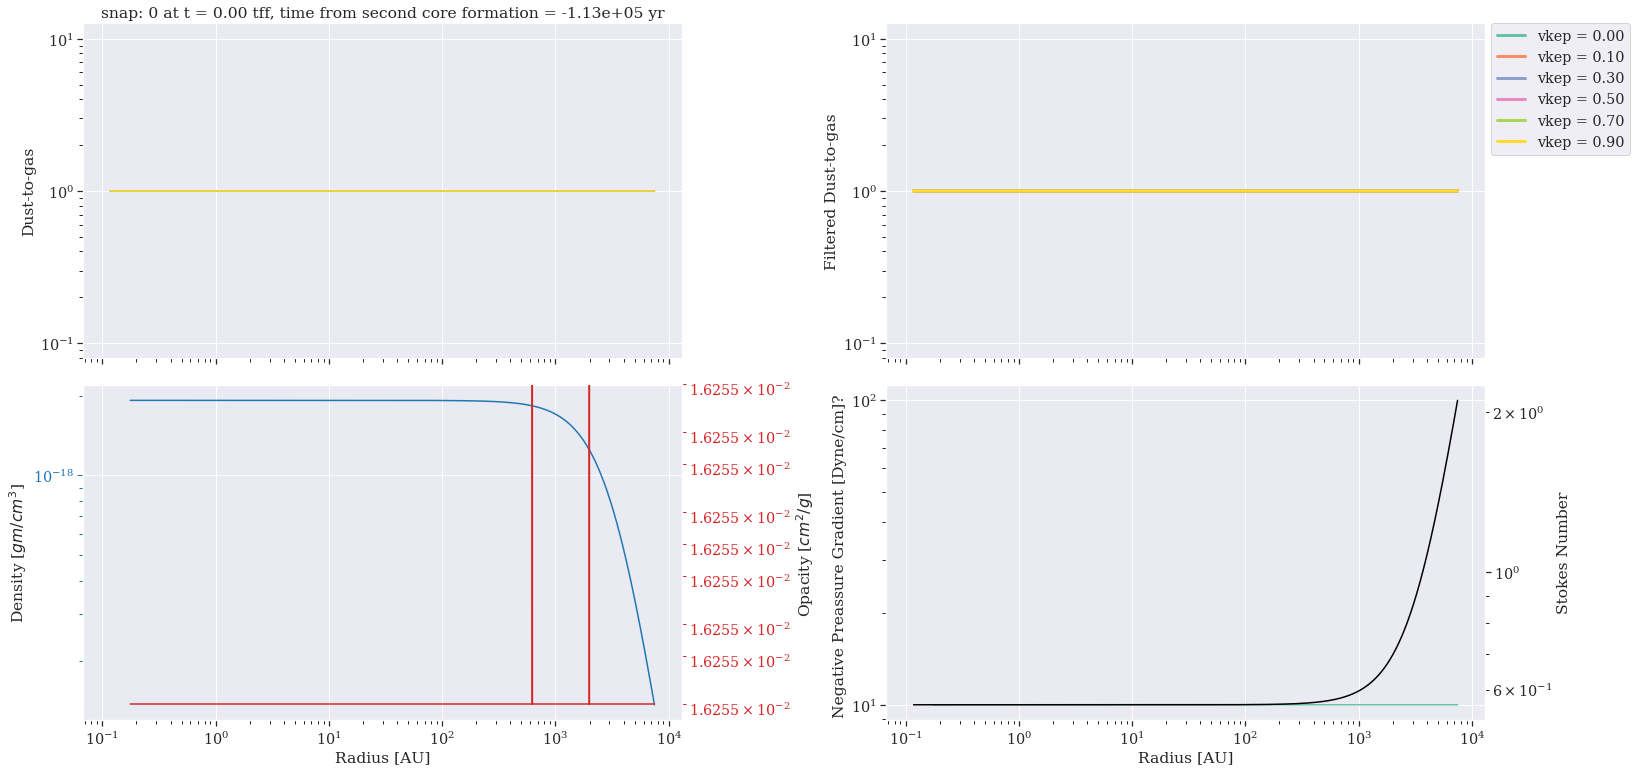

In [380]:
### Normed or not?
normed = 1
idsDir = -1
###
listi = [
         #'run006_large_Grains_4_pr_5bins_1000_0.00kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.10kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.30kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.50kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.70kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.90kep',
       ####
         #'run038_large_Grains_4_pr_5bins_1000_0.00kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.10kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.30kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.50kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.70kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.90kep',
       ####
         'run067_large_Grains_4_pr_5bins_1000_0.00kep',
         'run067_large_Grains_4_pr_5bins_1000_0.10kep',
         'run067_large_Grains_4_pr_5bins_1000_0.30kep',
         'run067_large_Grains_4_pr_5bins_1000_0.50kep',
         'run067_large_Grains_4_pr_5bins_1000_0.70kep',
         'run067_large_Grains_4_pr_5bins_1000_0.90kep',
       ####     
         #'run069_large_Grains_4_pr_5bins_1000_0.00kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.10kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.30kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.50kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.70kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.90kep'
        ]

#vdrift   = 0.5*sphere._rc[:-1,idsnap]*dpdr
#sphere._rc[:-1,idsnap]

# 0.5*r*dp/(vkep*rho) 
b,a      = scisig.butter(1, 0.1) # filter 0.01

dataPath = './DATA2/' 

sizeDir = os.listdir(dataPath+listi[0] + '/Snap0/')[:-1]
print("Plotting Size " + sizeDir[idsDir])
for size in sizeDir:
    size = sizeDir[2]
    sphere   = sim.DataSphere   ('../run_extracted/' + listi[0][:6] +  '/', units = sc.CGS)
    sphere._vg[:,:-1] = (sphere._rc[:,1:]-sphere._rc[:,:-1])/sphere.dt[None,:-1]
    sphere.update()
    at_sc    = np.argmax(sphere._T[0,:]>7000) # Look when Temp is > 7000K in center, ie second core formation
    tff      = np.sqrt(3*np.pi/(32 * sc.CGS.G * sphere._rho[0,0]))
    #########
    idsnap   = 0#200
    ########
    SDATA    = np.load('../run_extracted/' + listi[0][:6] +'/data.npy')
    opacity  = SDATA[:,7,:]
    preasure = SDATA[:,8,:]

    savePath = './plots/'+listi[0][:6]+'/'
    CreateDir(savePath)
    savePath += 'd2g/'
    CreateDir(savePath)
    
    minlim   = np.inf
    
    dp       = preasure  [1:,idsnap] - preasure  [:-1, idsnap]
    dr       = sphere._rc[1:,idsnap] - sphere._rc[:-1, idsnap]
    dpdr     = dp/dr
    
    ## create figure
    #if size != "9.99098e-02_cm":
    #    continue
    fig, ax = plt.subplots(2,2,sharex = True, figsize = (23,11))   
    axd2g, axfilt, axrho, axdpdr = ax.flatten()
    axopac = axrho.twinx(); axdrift = axdpdr.twinx()
    axopac.grid(False)    ; axdrift.grid(False)
    for file in listi:
        ## Load snap 0
        _, dust2g0, _, _ ,_ = np.loadtxt(dataPath + file + '/Snap0/'+size+'/d2g.txt', 
                                         unpack = True, skiprows = 2 ,  max_rows = None)
        ## load snap last (get from sphere)
        s, vkep , Mevap, MtotDust, Mlost = np.loadtxt(dataPath + file + '/Snap%i/'%(idsnap)+size+'/d2g.txt', 
                                                      unpack = True, skiprows = 1 ,  max_rows = 1)
        rc, dust2g, mdust, farray ,St    = np.loadtxt(dataPath + file + '/Snap%i/'%(idsnap)+size+'/d2g.txt', 
                                                      unpack = True, skiprows = 2 ,  max_rows = None)
        ## plot d2g, and filtered versions
        if (normed == 1):
            d2gnorm = dust2g/dust2g0
            axd2g .plot(rc/sc.CGS.AU, d2gnorm)
            filt = scisig.filtfilt(b, a, d2gnorm)
            axfilt.plot(rc/sc.CGS.AU, filt, label = "vkep = %.2f"%(vkep) , lw = 3)
            minlim = min(minlim, np.min(d2gnorm[
                                                #d2gnorm > 1e-1
                                                d2gnorm != 0
                                               ]) )
        else:
            axd2g .plot(rc/sc.CGS.AU, dust2g)
            filt = scisig.filtfilt(b, a, dust2g)
            axfilt.plot(rc/sc.CGS.AU, filt, label = "vkep = %.2f"%(vkep))
            minlim = min(minlim, np.min(dust2g[
                                               #dust2g > 1e-1
                                                dust2g != 0
                                              ]) )
    ## Sphere Left
    axrho .plot(sphere._rc[:,idsnap]/sc.CGS.AU, sphere._rho[:, idsnap], color = 'tab:blue', zorder = 2)
    axopac.plot(sphere._rc[:,idsnap]/sc.CGS.AU,      opacity[:,idsnap], color = 'tab:red' , zorder = 3)
    ## Sphere Right
    #axdpdr .plot(sphere._rc[:-1,idsnap]/sc.CGS.AU, -dpdr)
    axdpdr .plot(sphere._rc[:-1,idsnap]/sc.CGS.AU, sphere._T[:-1, idsnap])

    ## this is temp ST
    axdrift.plot(rc/sc.CGS.AU, St,color = 'black')
    #axdrift.plot(rc/sc.CGS.AU, np.ones_like(rc)*0.5,color = 'black', zorder = 1)      
    
    ### TITLE
    axd2g.set_title('snap: %i at t = %.2f tff, time from second core formation = %.2e yr' \
             %(idsnap, sphere.t[idsnap]/tff, (sphere.t[idsnap]-sphere.t[at_sc] )/sc.CGS.yr ))    
    # Scale
    ### Log
    axd2g .set_xscale('log')
    axd2g .set_yscale('log')
    axfilt.set_yscale('log')
    axrho .set_yscale('log')
    axdpdr.set_yscale('log')
    ##### Twin log
    axopac .set_yscale('log')
    axdrift.set_yscale('log')
    ###
    # xlabels
    axrho .set_xlabel('Radius [AU]')
    axdpdr.set_xlabel('Radius [AU]')
    ## ylabels
    axd2g  .set_ylabel( 'Dust-to-gas'         )
    axfilt .set_ylabel( 'Filtered Dust-to-gas')
    axrho  .set_ylabel(r'Density [$gm/cm^3$]')
    axdpdr .set_ylabel( 'Negative Preassure Gradient [Dyne/cm]? ')
    axopac .set_ylabel(r'Opacity [$cm^2/g$] ')
    #axdrift.set_ylabel( 'vdrift')
    axdrift.set_ylabel( 'Stokes Number')

    ###Ylim get
    ylim_new = axd2g.get_ylim()

    ### Evaporation line
    
    vkep, revap, Tevap = np.loadtxt(dataPath + file + '/Snap%i/Sphere-evap.txt'%(idsnap), unpack = True)
    if (revap != -1):
        alpha = 0.03 ; color = 'k'
        ## 1 d2g
        poly = patches.Rectangle((0,0), revap/sc.CGS.AU, 1e16, color = color, alpha = alpha,zorder = 1)
        axd2g .add_patch(poly)
        #txt = axd2g.text( revap/sc.CGS.AU*0.002 , ylim_new[1]*0.05, 'Evaporation Zone \n     T > %iK'%(Tevap))
        #txt.set_path_effects([PathEffects.withStroke(linewidth=5, foreground='w')])
        ## 2 d2g fitlered
        poly = patches.Rectangle((0,0), revap/sc.CGS.AU, 1e16, color = color, alpha = alpha,zorder = 1)
        axfilt.add_patch(poly)
        ## 3 dpdr
        poly = patches.Rectangle((0,0), revap/sc.CGS.AU, 1e16, color = color, alpha = alpha,zorder = 1)
        axdpdr.add_patch(poly)
        ## 4 opacity
        poly = patches.Rectangle((0,0), revap/sc.CGS.AU, 1e16, color = color, alpha = alpha,zorder = 1)
        axopac.add_patch(poly)

    
    ###Ylim
    axfilt.set_ylim(ylim_new)
    
    ### Ticks    
    ##### Left collumn
    axd2g.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = True, # turn off left ticks
                    right  = False,  # turn off right ticks
                    bottom = True) # turn off bottom ticks

    axrho.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = True, # turn off left ticks
                    right  = False,  # turn off right ticks
                    bottom = True) # turn off bottom ticks

    axopac.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = False, # turn off left ticks
                    right  = True,  # turn off right ticks
                    bottom = False) # turn off bottom ticks
    ##### Right collum
    axfilt.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = True, # turn off left ticks
                    right  = False,  # turn off right ticks
                    bottom = True) # turn off bottom ticks

    axdpdr.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = True, # turn off left ticks
                    right  = False,  # turn off right ticks
                    bottom = True) # turn off bottom ticks

    axdrift.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = False, # turn off left ticks
                    right  = True,  # turn off right ticks
                    bottom = False) # turn off bottom ticks
    ### Color Ticks
    ##### Left Collumn
    axrho.tick_params(axis = 'y', colors = 'tab:blue' ,width = 1, which = 'both')
    axopac.tick_params(axis = 'y', colors = 'tab:red'  ,width = 1, which = 'both')    
    ##### 
    
    ## LEGEND
    axfilt.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', borderaxespad = 0.)
    ##
    ###
    if normed == 0:
        minlim = max(minlim, 5e-4)
    #axfilt.set_ylim(bottom = minlim,
                    #top    = 1e5
                    #top    = 2e2
                  # )
    #axd2g .set_ylim(bottom = minlim,
                    #top    = 1e5
                    #top    = 2e2
                  # )
    

    fig.tight_layout()
    fig.subplots_adjust(hspace = 0.08)
    
    plotPath = savePath + size + "/"
    CreateDir(plotPath)
    plotPath += "Snap%i/"%(idsnap)
    CreateDir(plotPath)
    if (normed == 1 ): fig.savefig(plotPath + "d2g_4x4_Normed.png")
    else:              fig.savefig(plotPath + "d2g_4x4.png")
    #plt.close('all')
    break
print('Plotting Done')

In [127]:
PlotLim={                # [Raw       ,    Normed]
    "run006": {          #  (bot, top)
        '1.58346e-02_cm' : [ (9e-4, 3e-3)  ,  ( 4e-1, 2e0 ) ],
        '2.50962e-03_cm' : [ (3e-4, 2e-3)  ,  ( 5e-1, 2e0 ) ],
        '3.97748e-02_cm' : [ (1e-3, 4e-3)  ,  ( 5e-1, 2e0 ) ],
        '6.30388e-03_cm' : [ (4e-4, 2e-3)  ,  ( 5e-1, 2e0 ) ],
        '9.99098e-02_cm' : [ (2e-3, 2e-2)  ,  ( 5e-1, 3e0 ) ],
    },
    "run038": {
        '1.58346e-02_cm' : [ (5e-4  , 5e-3  )  ,  (4e-1, 4e0  ) ],
        '2.50962e-03_cm' : [ (2e-4  , 2e-3  )  ,  (3e-1, 2.5e0) ],
        '3.97748e-02_cm' : [ (1.5e-3, 2e-2  )  ,  (6e-1, 5e0  ) ],
        '6.30388e-03_cm' : [ (3e-4  , 2.5e-3)  ,  (3e-1, 3e0  ) ],
        '9.99098e-02_cm' : [ (2e-3  , 1e-1  )  ,  (5e-1, 2e1  ) ],
    },
    "run067": {
        '1.58346e-02_cm' : [ (1e-3, 2e-2  )  ,  ( 6e-1, 1.2e1) ],
        '2.50962e-03_cm' : [ (2e-4, 2.5e-3)  ,  ( 3e-1, 3e0  ) ],
        '3.97748e-02_cm' : [ (1e-3, 2.5e-1)  ,  ( 3e-1, 1e2  ) ],
        '6.30388e-03_cm' : [ (4e-4, 5e-3  )  ,  ( 4e-1, 5e0  ) ],
        '9.99098e-02_cm' : [ (1e-4, 1e3   )  ,  ( 1e-1, 1e5  ) ],
    },
    "run069": {
        '1.58346e-02_cm' : [ (1e-3, 4e-3  )  ,  (6e-1, 2.5e0) ],
        '2.50962e-03_cm' : [ (4e-4, 1.2e-3)  ,  (5e-1, 2e0  ) ],
        '3.97748e-02_cm' : [ (2e-3, 1e-2  )  ,  (6e-1, 3.5e0) ],
        '6.30388e-03_cm' : [ (6e-4, 2e-3  )  ,  (5e-1, 2.2e0) ],
        '9.99098e-02_cm' : [ (2e-3, 6e-2  )  ,  (6e-1, 1.5e1 )  ],
    },
}


In [139]:
### Normed or not?
normed = 0
idsDir = -1
###
listi = [
         'run006_large_Grains_4_pr_5bins_1000_0.00kep',
         'run006_large_Grains_4_pr_5bins_1000_0.10kep',
         'run006_large_Grains_4_pr_5bins_1000_0.30kep',
         'run006_large_Grains_4_pr_5bins_1000_0.50kep',
         'run006_large_Grains_4_pr_5bins_1000_0.70kep',
         'run006_large_Grains_4_pr_5bins_1000_0.90kep',
       ####
         #'run038_large_Grains_4_pr_5bins_1000_0.00kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.10kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.30kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.50kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.70kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.90kep',
       ####
         #'run067_large_Grains_4_pr_5bins_1000_0.00kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.10kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.30kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.50kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.70kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.90kep',
       ####     
         #'run069_large_Grains_4_pr_5bins_1000_0.00kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.10kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.30kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.50kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.70kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.90kep'
        ]

#vdrift   = 0.5*sphere._rc[:-1,idsnap]*dpdr
#sphere._rc[:-1,idsnap]

# 0.5*r*dp/(vkep*rho) 
b,a      = scisig.butter(1, 0.1) # filter 0.01

dataPath = './DATA2/' 

sizeDir = os.listdir(dataPath+listi[0] + '/Snap0/')[:-1]
print("Plotting run " + listi[0][:6], "Normed = %r"%(normed))
for size in sizeDir:
    #size = sizeDir[-1]
    sphere   = sim.DataSphere   ('../run_extracted/' + listi[0][:6] +  '/', units = sc.CGS)
    sphere._vg[:,:-1] = (sphere._rc[:,1:]-sphere._rc[:,:-1])/sphere.dt[None,:-1]
    sphere.update()
    at_sc    = np.argmax(sphere._T[0,:]>7000) # Look when Temp is > 7000K in center, ie second core formation
    tff      = np.sqrt(3*np.pi/(32 * sc.CGS.G * sphere._rho[0,0]))
    #########
    idsnap   = sphere.nsteps - 1
    ########
    SDATA    = np.load('../run_extracted/' + listi[0][:6] +'/data.npy')
    opacity  = SDATA[:,7,:]
    preasure = SDATA[:,8,:]

    savePath = './plots/'+listi[0][:6]+'/'
    CreateDir(savePath)
    savePath += 'd2g/'
    CreateDir(savePath)
    
    minlim   = np.inf
    
    dp       = preasure  [1:,idsnap] - preasure  [:-1, idsnap]
    dr       = sphere._rc[1:,idsnap] - sphere._rc[:-1, idsnap]
    dpdr     = dp/dr
    
    ## create figure
    #if size != "9.99098e-02_cm":
    #    continue
    fig, ax = plt.subplots(2,2,sharex = True, figsize = (23,11))   
    axd2g, axfilt, axrho, axdpdr = ax.flatten()
    axopac = axrho.twinx(); axdrift = axdpdr.twinx()
    axopac.grid(False)    ; axdrift.grid(False)
    for file in listi:
        ## Load snap 0
        _, dust2g0, _, _ ,_ = np.loadtxt(dataPath + file + '/Snap0/'+size+'/d2g.txt', 
                                         unpack = True, skiprows = 2 ,  max_rows = None)
        ## load snap last (get from sphere)
        s, vkep , Mevap, MtotDust, Mlost = np.loadtxt(dataPath + file + '/Snap%i/'%(idsnap)+size+'/d2g.txt', 
                                                      unpack = True, skiprows = 1 ,  max_rows = 1)
        rc, dust2g, mdust, farray ,St    = np.loadtxt(dataPath + file + '/Snap%i/'%(idsnap)+size+'/d2g.txt', 
                                                      unpack = True, skiprows = 2 ,  max_rows = None)
        ## plot d2g, and filtered versions
        if (normed == 1):
            d2gnorm = dust2g/dust2g0
            axd2g .plot(rc/sc.CGS.AU, d2gnorm)
            filt = scisig.filtfilt(b, a, d2gnorm)
            axfilt.plot(rc/sc.CGS.AU, filt, label = "vkep = %.2f"%(vkep) , lw = 3)
            minlim = min(minlim, np.min(d2gnorm[
                                                #d2gnorm > 1e-1
                                                d2gnorm != 0
                                               ]) )
        else:
            axd2g .plot(rc/sc.CGS.AU, dust2g)
            filt = scisig.filtfilt(b, a, dust2g)
            axfilt.plot(rc/sc.CGS.AU, filt, label = "vkep = %.2f"%(vkep))
            minlim = min(minlim, np.min(dust2g[
                                               #dust2g > 1e-1
                                                dust2g != 0
                                              ]) )
    ## Sphere Left
    axrho .plot(sphere._rc[:,idsnap]/sc.CGS.AU, sphere._rho[:, idsnap], color = 'tab:blue', zorder = 2)
    axopac.plot(sphere._rc[:,idsnap]/sc.CGS.AU,      opacity[:,idsnap], color = 'tab:red' , zorder = 3)
    ## Sphere Right
    #axdpdr .plot(sphere._rc[:-1,idsnap]/sc.CGS.AU, -dpdr)
    axdpdr .plot(sphere._rc[:-1,idsnap]/sc.CGS.AU, sphere._T[:-1, idsnap])

    ## this is temp ST
    axdrift.plot(rc/sc.CGS.AU, St,color = 'black')
    #axdrift.plot(rc/sc.CGS.AU, np.ones_like(rc)*0.5,color = 'black', zorder = 1)      
    
    ### TITLE
    axd2g.set_title('snap: %i at t = %.2f tff, time from second core formation = %.2e yr' \
             %(idsnap, sphere.t[idsnap]/tff, (sphere.t[idsnap]-sphere.t[at_sc] )/sc.CGS.yr ))    
    # Scale
    ### Log
    axd2g .set_xscale('log')
    axd2g .set_yscale('log')
    axfilt.set_yscale('log')
    axrho .set_yscale('log')
    axdpdr.set_yscale('log')
    ##### Twin log
    axopac .set_yscale('log')
    axdrift.set_yscale('log')
    ###
    # xlabels
    axrho .set_xlabel('Radius [AU]')
    axdpdr.set_xlabel('Radius [AU]')
    ## ylabels
    axd2g  .set_ylabel( 'Dust-to-gas'         )
    axfilt .set_ylabel( 'Filtered Dust-to-gas')
    axrho  .set_ylabel(r'Density [$gm/cm^3$]')
    axdpdr .set_ylabel( 'Negative Preassure Gradient [Dyne/cm]? ')
    axopac .set_ylabel(r'Opacity [$cm^2/g$] ')
    #axdrift.set_ylabel( 'vdrift')
    axdrift.set_ylabel( 'Stokes Number')

    ###Ylim get
    ylim_new = axd2g.get_ylim()

    ### Evaporation line
    
    vkep, revap, Tevap = np.loadtxt(dataPath + file + '/Snap%i/Sphere-evap.txt'%(idsnap), unpack = True)
    if (revap != -1):
        alpha = 0.03 ; color = 'k'
        ## 1 d2g
        poly = patches.Rectangle((0,0), revap/sc.CGS.AU, 1e16, color = color, alpha = alpha,zorder = 1)
        axd2g .add_patch(poly)
        #txt = axd2g.text( revap/sc.CGS.AU*0.002 , ylim_new[1]*0.05, 'Evaporation Zone \n     T > %iK'%(Tevap))
        #txt.set_path_effects([PathEffects.withStroke(linewidth=5, foreground='w')])
        ## 2 d2g fitlered
        poly = patches.Rectangle((0,0), revap/sc.CGS.AU, 1e16, color = color, alpha = alpha,zorder = 1)
        axfilt.add_patch(poly)
        ## 3 dpdr
        poly = patches.Rectangle((0,0), revap/sc.CGS.AU, 1e16, color = color, alpha = alpha,zorder = 1)
        axdpdr.add_patch(poly)
        ## 4 opacity
        poly = patches.Rectangle((0,0), revap/sc.CGS.AU, 1e16, color = color, alpha = alpha,zorder = 1)
        axopac.add_patch(poly)
    ###Ylim
    axfilt.set_ylim(ylim_new)
    
    ### Ticks    
    ##### Left collumn
    axd2g.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = True, # turn off left ticks
                    right  = False,  # turn off right ticks
                    bottom = True) # turn off bottom ticks

    axrho.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = True, # turn off left ticks
                    right  = False,  # turn off right ticks
                    bottom = True) # turn off bottom ticks

    axopac.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = False, # turn off left ticks
                    right  = True,  # turn off right ticks
                    bottom = False) # turn off bottom ticks
    ##### Right collum
    axfilt.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = True, # turn off left ticks
                    right  = False,  # turn off right ticks
                    bottom = True) # turn off bottom ticks

    axdpdr.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = True, # turn off left ticks
                    right  = False,  # turn off right ticks
                    bottom = True) # turn off bottom ticks

    axdrift.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = False, # turn off left ticks
                    right  = True,  # turn off right ticks
                    bottom = False) # turn off bottom ticks
    ### Color Ticks
    ##### Left Collumn
    axrho.tick_params(axis = 'y', colors = 'tab:blue' ,width = 1, which = 'both')
    axopac.tick_params(axis = 'y', colors = 'tab:red'  ,width = 1, which = 'both')    
    ##### 

    ## LEGEND
    axfilt.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', borderaxespad = 0.)
    ##
    ###
    if normed == 0:
        minlim = max(minlim, 5e-4)
        
    axfilt.set_ylim(bottom = PlotLim[file[:6]][size][normed][0],
                    top    = PlotLim[file[:6]][size][normed][1]
                    #top    = 1e5
                    #top    = 2e2
                   )
    axd2g .set_ylim(bottom = PlotLim[file[:6]][size][normed][0],
                    top    = PlotLim[file[:6]][size][normed][1]
                    #top    = 1e5
                    #top    = 2e2
                   )
    

    fig.tight_layout()
    fig.subplots_adjust(hspace = 0.08)
    
    plotPath = savePath + size + "/"
    CreateDir(plotPath)
    plotPath += "Snap%i/"%(idsnap)
    CreateDir(plotPath)
    if (normed == 1 ): fig.savefig(plotPath + "d2g_4x4_Normed.png")
    else:              fig.savefig(plotPath + "d2g_4x4.png")
    plt.close('all')
    #break
print('Plotting Done')

Plotting run run006 Normed = 0
Plotting Done


In [78]:
file[:6]

'run006'

In [86]:
PlotLim[file[:6]][size][normed]

(0.002, 0.02)

In [ ]:
# M Evap corparison
dataPath = './DATA2/' 
listi = [
         #'run006_large_Grains_4_pr_5bins_1000_0.00kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.10kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.30kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.50kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.70kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.90kep',
       ####
         #run038_large_Grains_4_pr_5bins_1000_0.00kep',
         #run038_large_Grains_4_pr_5bins_1000_0.10kep',
         #run038_large_Grains_4_pr_5bins_1000_0.30kep',
         #run038_large_Grains_4_pr_5bins_1000_0.50kep',
         #run038_large_Grains_4_pr_5bins_1000_0.70kep',
         #run038_large_Grains_4_pr_5bins_1000_0.90kep',
       ####
         #run067_large_Grains_4_pr_5bins_1000_0.00kep',
         #run067_large_Grains_4_pr_5bins_1000_0.10kep',
         #run067_large_Grains_4_pr_5bins_1000_0.30kep',
         #run067_large_Grains_4_pr_5bins_1000_0.50kep',
         #run067_large_Grains_4_pr_5bins_1000_0.70kep',
         #run067_large_Grains_4_pr_5bins_1000_0.90kep',
       ####     
         'run069_large_Grains_4_pr_5bins_1000_0.00kep',
         'run069_large_Grains_4_pr_5bins_1000_0.10kep',
         'run069_large_Grains_4_pr_5bins_1000_0.30kep',
         'run069_large_Grains_4_pr_5bins_1000_0.50kep',
         'run069_large_Grains_4_pr_5bins_1000_0.70kep',
         'run069_large_Grains_4_pr_5bins_1000_0.90kep'
        ]
colorDict = {
             'run067': 'tab:red',
             'run006': 'tab:blue', 
             'run038': 'tab:green',
            }

shapeDict = {
             '0.00'  : 'o-',
             '0.10'  : '^-', 
             '0.30'  : 's-',
             '0.50'  : '*-',
             '0.70'  : 'X-', 
             '0.90'  : 'D-',
            }


evapDATA = {          # Mevp s  kvep  mlost, Mtot
             'run067': [ [], [], [], [], [] ],
             'run006': [ [], [], [], [], [] ], 
             'run038': [ [], [], [], [], [] ],
            }
for file in listi:
    run  = file[:6]    
    path = dataPath + file + "/Snap%i/"%(idsnap)
    for size in os.listdir(path)[:-1]:
        sizePath = path + size
        
        
        sphere   = sim.DataSphere   ('../run_extracted/' + file[:6] +  '/', units = sc.CGS)
        sphere._vg[:,:-1] = (sphere._rc[:,1:]-sphere._rc[:,:-1])/sphere.dt[None,:-1]
        sphere.update()

        s, vkep , Mevap, MtotDust, Mlost = np.loadtxt(sizePath + '/d2g.txt', 
                                                      unpack = True, skiprows = 1 ,  max_rows = 1)
        evapDATA[run][0].append(Mevap   ) # Mevap
        evapDATA[run][1].append(s       ) # size  
        evapDATA[run][2].append(vkep    ) # vkep
        evapDATA[run][3].append(Mlost   ) # Mlost 
        evapDATA[run][4].append(MtotDust) # Mtot
    print("Done With file :",file)
for key in evapDATA.keys():
    evapDATA[key][0] = np.array(evapDATA[key][0])
    evapDATA[key][1] = np.array(evapDATA[key][1])
    evapDATA[key][2] = np.array(evapDATA[key][2])
    evapDATA[key][3] = np.array(evapDATA[key][3])
    evapDATA[key][4] = np.array(evapDATA[key][4])
print('Done collecting')

In [ ]:
for key in evapDATA.keys():
    evapDATA[key][0] = np.array(evapDATA[key][0])
    evapDATA[key][1] = np.array(evapDATA[key][1])
    evapDATA[key][2] = np.array(evapDATA[key][2])
    evapDATA[key][3] = np.array(evapDATA[key][3])
    evapDATA[key][4] = np.array(evapDATA[key][4])

In [ ]:
shapeDict = {
             0.0  : 'o-'  ,
             0.1  : '^-' , 
             0.3  : 's-',
             0.5  : '*-'  ,
             0.7  : 'X-' , 
             0.9  : 'D-',
            }

In [ ]:
fig, (ax0, ax1)= plt.subplots(1,2, figsize=  (14,6))
for vkep_ in np.unique(evapDATA["run067"][2]):
    
    idx = np.argsort(evapDATA["run067"][1][evapDATA["run067"][2] == vkep_])  
    ax0.plot(
             cm_to_microns(evapDATA["run067"][1][evapDATA["run067"][2] == vkep_][idx]),
             evapDATA["run067"][0][evapDATA["run067"][2] == vkep_][idx]/evapDATA["run067"][4][evapDATA["run067"][2] == vkep_][idx],
             shapeDict[vkep_], ms = 8 ,label = "run067: vkep = %.2f"%(vkep_), 
             #color = colorDict["run067"]
             )
    
for ss in np.unique(evapDATA["run067"][1]):
    
    idx = np.argsort(evapDATA["run067"][2][evapDATA["run067"][1] == ss]) 
    ax1.plot(
             evapDATA["run067"][2][evapDATA["run067"][1] == ss][idx],
             evapDATA["run067"][0][evapDATA["run067"][1] == ss][idx]/evapDATA["run067"][4][evapDATA["run067"][1] == ss][idx],
             shapeDict[vkep], ms = 8 ,label = r"run067: s = %.2e $\mu m$"%(cm_to_microns(ss)), 
             #color = colorDict["run067"]
             )


ax0.set_xlabel(r'Size [$\mu$m]')
ax1.set_xlabel(r'Vkep [%]')

ax0.set_ylabel(r'Evaporated mass, $M_{tot}(r< r_{evap})/M_{tot}$', Fontsize = 18)

ax0.legend(bbox_to_anchor = (2.21, 0.58), loc = 'upper left', borderaxespad = 0.)
ax1.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', borderaxespad = 0.)
plt.show()

In [ ]:
Mg = sphere._M[(sphere._rc[:,813]/sc.CGS.AU < 0.8),813]

In [ ]:
sphere._M[:,813]

In [ ]:
plt.plot(sphere._rc[(sphere._rc[:,813]/sc.CGS.AU < 0.8),813]/sc.CGS.AU ,Mg/sphere._M[-1,813])

In [ ]:
0.7/0.02*0.01

In [ ]:
dataPath = './DATA2/'


In [ ]:
cartisian_to_polar_velocity

In [ ]:
ss = np.loadtxt('../simData/' + file +'/s.txt', max_rows=  1) ; print("\t ss Done" )

In [ ]:
ll = [
        'run006_large_Grains_4_pr_5bins_1000_0.00kep',
        'run038_large_Grains_4_pr_5bins_1000_0.00kep',
        'run067_large_Grains_4_pr_5bins_1000_0.00kep',
        'run069_large_Grains_4_pr_5bins_1000_0.00kep',
]

for file in ll:
    ss = np.loadtxt('../simData/' + file +'/s.txt', max_rows=  1) 
    print(cm_to_microns(np.unique(ss)),'microns',' \t ', file)


In [3]:
listi = [
         'run067_large_Grains_4_pr_5bins_1000_0.00kep',
         'run067_large_Grains_4_pr_5bins_1000_0.10kep',
         'run067_large_Grains_4_pr_5bins_1000_0.30kep',
         'run067_large_Grains_4_pr_5bins_1000_0.50kep',
         'run067_large_Grains_4_pr_5bins_1000_0.70kep',
         'run067_large_Grains_4_pr_5bins_1000_0.90kep',
        ]
file = listi[1]
ss = np.loadtxt('../simData/' + file +'/s.txt', max_rows=  1) ; print("\t ss Done" )
x  = np.loadtxt('../simData/' + file +'/x.txt' )              ; print("\t  x Done" )
y  = np.loadtxt('../simData/' + file +'/y.txt' )              ; print("\t  y Done" )
vx = np.loadtxt('../simData/' + file +'/vx.txt')              ; print("\t vx Done")
vy = np.loadtxt('../simData/' + file +'/vy.txt')              ; print("\t vy Done")
St = np.loadtxt('../simData/' + file +'/St.txt')              ; print("\t Stokes Done")
t  = np.loadtxt('../simData/' + file +'/time.txt')             ; print('\t time done')
pm = np.loadtxt('../simData/' + file +'/mass.txt')           ; print("\t mass done" )
r  = radius(x,y)                                              ; print("\t  r Done" )
vr, vphi = cartisian_to_polar_velocity(x,y,r,vx,vy)           ; print("\t Polar done")

s_unique = np.unique(ss)
smask    = (ss == s_unique[-1])

dataPath = './DATA2/'

print("all done")

	 ss Done


KeyboardInterrupt: 

In [ ]:
sphere = sim.DataSphere   ('../run_extracted/run067/', units = sc.CGS)
sphere._vg[:,:-1] = (sphere._rc[:,1:]-sphere._rc[:,:-1])/sphere.dt[None,:-1]
sphere.update()

In [ ]:
file = listi[0]
print('../simData/' + file +'/vx.txt')
x  = np.loadtxt('../simData/' + file +'/x.txt' )              ; print("\t  x Done" )
y  = np.loadtxt('../simData/' + file +'/y.txt' )              ; print("\t  y Done" )
r  = radius(x,y)                                              ; print("\t  r Done" )
vx = np.loadtxt('../simData/' + file +'/vx.txt')              ; print("\t vx Done")
vy = np.loadtxt('../simData/' + file +'/vy.txt')              ; print("\t vy Done")
vr, vphi = cartisian_to_polar_velocity(x,y,r,vx,vy)           ; print("\t Polar done")

In [ ]:
file = listi[1]
print('../simData/' + file +'/vx.txt')
x1  = np.loadtxt('../simData/' + file +'/x.txt' )              ; print("\t  x Done" )
y1  = np.loadtxt('../simData/' + file +'/y.txt' )              ; print("\t  y Done" )
r1  = radius(x1,y1)                                              ; print("\t  r Done" )
vx1 = np.loadtxt('../simData/' + file +'/vx.txt')              ; print("\t vx Done")
vy1 = np.loadtxt('../simData/' + file +'/vy.txt')              ; print("\t vy Done")
vr1, vphi1 = cartisian_to_polar_velocity(x1,y1,r1,vx1,vy1)           ; print("\t Polar done")

In [ ]:
idx = 28
#plt.plot(  r[idx,smask]/sc.CGS.AU , ( vr[idx,smask]) ,'o' , color = 'r' )
plt.plot( r1[idx,smask]/sc.CGS.AU, ( vr1[idx,smask]) ,'.' , color = 'k' )
plt.xscale('log')

In [ ]:
idx = 30

rc, dust2g, mdust, _ ,_    = np.loadtxt(dataPath + file + '/Snap%i/'%(idx)+'9.99098e-02_cm'+'/d2g.txt', 
                                              unpack = True, skiprows = 2 ,  max_rows = None)


fig, (ax3, ax0, ax2) = plt.subplots(3,1, figsize = (14,12), sharex = True)
ax1 = ax0.twinx()

ax0.plot( np.abs( r[idx,smask])/sc.CGS.AU, ( vr[idx,smask]),'.' , color = 'k' )

ax2.plot( np.abs( r[idx,smask])/sc.CGS.AU ,   np.abs( St[idx,smask]) )
ax4 = ax2.twinx()
ax4.plot( sphere._rc[:,idx]/sc.CGS.AU, sphere._rho[:,idx]       , color = 'r' , lw = 3)


ax3.plot(rc/sc.CGS.AU,dust2g)

ax0.set_xscale('log')
ax2.set_xscale('log')
ax3.set_xscale('log')
ax3.set_yscale('log')

ax1.grid(False)

In [ ]:
idx = 28

rc, dust2g, mdust, _ ,_    = np.loadtxt(dataPath + file + '/Snap%i/'%(idx)+'9.99098e-02_cm'+'/d2g.txt', 
                                              unpack = True, skiprows = 2 ,  max_rows = None)

fig, (ax3, ax0, ax2) = plt.subplots(3,1, figsize = (14,12), sharex = True)
#ax1 = ax0.twinx()

ax0.plot( np.abs( r[idx,smask])/sc.CGS.AU, ( vr[idx,smask]),'.' , color = 'k' )
#ax0.plot( np.abs( r[idx,smask])/sc.CGS.AU, ( vphi[idx,smask]),'.' , color = 'k' )
ax0.plot( sphere._rc[:,idx]/sc.CGS.AU, sphere._vg[:,idx]       , color = 'r' , lw = 3, zorder = 1)

ax2.plot( np.abs( r[idx,smask])/sc.CGS.AU ,   np.abs( St[idx,smask]) )

ax3.plot(rc/sc.CGS.AU,dust2g)
ax4 = ax2.twinx()
ax4.plot( sphere._rc[:,idx]/sc.CGS.AU, sphere._rho[:,idx]       , color = 'r' , lw = 3)

ax0.set_ylim([-1000,1000])
#ax0.set_xlim([1e-5,7e3])
ax0.set_xscale('log')
ax2.set_xscale('log')
ax3.set_xscale('log')
ax3.set_yscale('log')

ax2.set_ylabel('St')

ax4.grid(False)
ax1.grid(False)

In [ ]:
idx = 29

rc, dust2g, mdust, _ ,_    = np.loadtxt(dataPath + file + '/Snap%i/'%(idx)+'9.99098e-02_cm'+'/d2g.txt', 
                                              unpack = True, skiprows = 2 ,  max_rows = None)

fig, (ax3, ax0, ax2) = plt.subplots(3,1, figsize = (14,12), sharex = True)
#ax1 = ax0.twinx()

ax0.plot( np.abs( r[idx,smask])/sc.CGS.AU, ( vr[idx,smask]),'.' , color = 'k' )
#ax0.plot( np.abs( r[idx,smask])/sc.CGS.AU, ( vphi[idx,smask]),'.' , color = 'k' )
ax0.plot( sphere._rc[:,idx]/sc.CGS.AU, sphere._vg[:,idx]       , color = 'r' , lw = 3, zorder = 1)

ax2.plot( np.abs( r[idx,smask])/sc.CGS.AU ,   np.abs( St[idx,smask]) )

ax3.plot(rc/sc.CGS.AU,dust2g)
ax4 = ax2.twinx()
ax4.plot( sphere._rc[:,idx]/sc.CGS.AU, sphere._rho[:,idx]       , color = 'r' , lw = 3)

ax0.set_ylim([-3000,3000])
#ax0.set_xlim([1e-5,7e3])
ax0.set_xscale('log')
ax2.set_xscale('log')
ax3.set_xscale('log')
ax3.set_yscale('log')

ax2.set_ylabel('St')

ax4.grid(False)
ax1.grid(False)

In [ ]:
idx = 30

rc, dust2g, mdust, _ ,_    = np.loadtxt(dataPath + file + '/Snap%i/'%(idx)+'9.99098e-02_cm'+'/d2g.txt', 
                                              unpack = True, skiprows = 2 ,  max_rows = None)

fig, (ax3, ax0, ax2) = plt.subplots(3,1, figsize = (14,12), sharex = True)
#ax1 = ax0.twinx()

ax0.plot( np.abs( r[idx,smask])/sc.CGS.AU, ( vr[idx,smask]),'.' , color = 'k' )
#ax0.plot( np.abs( r[idx,smask])/sc.CGS.AU, ( vphi[idx,smask]),'.' , color = 'k' )
ax0.plot( sphere._rc[:,idx]/sc.CGS.AU, sphere._vg[:,idx]       , color = 'r' , lw = 3, zorder = 1)

ax2.plot( np.abs( r[idx,smask])/sc.CGS.AU ,   np.abs( St[idx,smask]) )

ax3.plot(rc/sc.CGS.AU,dust2g)
ax4 = ax2.twinx()
ax4.plot( sphere._rc[:,idx]/sc.CGS.AU, sphere._rho[:,idx]       , color = 'r' , lw = 3)

ax0.set_ylim([-3000,3000])
#ax0.set_xlim([1e-5,7e3])
ax0.set_xscale('log')
ax2.set_xscale('log')
ax3.set_xscale('log')
ax3.set_yscale('log')

ax2.set_ylabel('St')

ax4.grid(False)
ax1.grid(False)

In [ ]:
idx = 31

rc, dust2g, mdust, _ ,_    = np.loadtxt(dataPath + file + '/Snap%i/'%(idx)+'9.99098e-02_cm'+'/d2g.txt', 
                                              unpack = True, skiprows = 2 ,  max_rows = None)

fig, (ax3, ax0, ax2) = plt.subplots(3,1, figsize = (14,12), sharex = True)
#ax1 = ax0.twinx()

ax0.plot( np.abs( r[idx,smask])/sc.CGS.AU, ( vr[idx,smask]),'.' , color = 'k' )
#ax0.plot( np.abs( r[idx,smask])/sc.CGS.AU, ( vphi[idx,smask]),'.' , color = 'k' )
ax0.plot( sphere._rc[:,idx]/sc.CGS.AU, sphere._vg[:,idx]       , color = 'r' , lw = 3, zorder = 1)

ax2.plot( np.abs( r[idx,smask])/sc.CGS.AU ,   np.abs( St[idx,smask]) )

ax3.plot(rc/sc.CGS.AU,dust2g)
ax4 = ax2.twinx()
ax4.plot( sphere._rc[:,idx]/sc.CGS.AU, sphere._rho[:,idx]       , color = 'r' , lw = 3)

ax0.set_ylim([-3000,3000])
#ax0.set_xlim([1e-5,7e3])
ax0.set_xscale('log')
ax2.set_xscale('log')
ax3.set_xscale('log')
ax3.set_yscale('log')

ax2.set_ylabel('St')

ax4.grid(False)
ax1.grid(False)

In [ ]:
idx = 32

rc, dust2g, mdust, _ ,_    = np.loadtxt(dataPath + file + '/Snap%i/'%(idx)+'9.99098e-02_cm'+'/d2g.txt', 
                                              unpack = True, skiprows = 2 ,  max_rows = None)

fig, (ax3, ax0, ax2) = plt.subplots(3,1, figsize = (14,12), sharex = True)
#ax1 = ax0.twinx()

ax0.plot( np.abs( r[idx,smask])/sc.CGS.AU, ( vr[idx,smask]),'.' , color = 'k' )
#ax0.plot( np.abs( r[idx,smask])/sc.CGS.AU, ( vphi[idx,smask]),'.' , color = 'k' )
ax0.plot( sphere._rc[:,idx]/sc.CGS.AU, sphere._vg[:,idx]       , color = 'r' , lw = 3, zorder = 1)

ax2.plot( np.abs( r[idx,smask])/sc.CGS.AU ,   np.abs( St[idx,smask]) )

ax3.plot(rc/sc.CGS.AU,dust2g)
ax4 = ax2.twinx()
ax4.plot( sphere._rc[:,idx]/sc.CGS.AU, sphere._rho[:,idx]       , color = 'r' , lw = 3)

ax0.set_ylim([-3000,5000])
#ax0.set_xlim([1e-5,7e3])
ax0.set_xscale('log')
ax2.set_xscale('log')
ax3.set_xscale('log')
ax3.set_yscale('log')

ax2.set_ylabel('St')

ax4.grid(False)
ax1.grid(False)

In [ ]:
idx = 34

rc, dust2g, mdust, _ ,_    = np.loadtxt(dataPath + file + '/Snap%i/'%(idx)+'9.99098e-02_cm'+'/d2g.txt', 
                                              unpack = True, skiprows = 2 ,  max_rows = None)

fig, (ax3, ax0, ax2) = plt.subplots(3,1, figsize = (14,12), sharex = True)
#ax1 = ax0.twinx()

ax0.plot( np.abs( r[idx,smask])/sc.CGS.AU, ( vr[idx,smask]),'.' , color = 'k' )
#ax0.plot( np.abs( r[idx,smask])/sc.CGS.AU, ( vphi[idx,smask]),'.' , color = 'k' )
ax0.plot( sphere._rc[:,idx]/sc.CGS.AU, sphere._vg[:,idx]       , color = 'r' , lw = 3, zorder = 1)

ax2.plot( np.abs( r[idx,smask])/sc.CGS.AU ,   np.abs( St[idx,smask]) )

ax3.plot(rc/sc.CGS.AU,dust2g)
ax4 = ax2.twinx()
ax4.plot( sphere._rc[:,idx]/sc.CGS.AU, sphere._rho[:,idx]       , color = 'r' , lw = 3)

ax0.set_ylim([-3000,5000])
#ax0.set_xlim([1e-5,7e3])
ax0.set_xscale('log')
ax2.set_xscale('log')
ax3.set_xscale('log')
ax3.set_yscale('log')

ax2.set_ylabel('St')

ax4.grid(False)
ax1.grid(False)

In [ ]:
idx = 26
plt.figure(figsize = (14,6))
plt.plot( np.abs( r[idx,smask])  /sc.CGS.AU, ( vr[idx,smask]),'-' )
plt.plot( np.abs( r[idx+1,smask])/sc.CGS.AU, ( vr[idx+1,smask]),'-' )
plt.plot( np.abs( r[idx+2,smask])/sc.CGS.AU, ( vr[idx+2,smask]),'-' )
#plt.plot( np.abs( r[idx+3,smask])/sc.CGS.AU, ( vr[idx,smask]),'.' )

#ax0.plot( np.abs( r[idx,smask])/sc.CGS.AU, ( vphi[idx,smask]),'.' , color = 'k' )
#plt.plot( sphere._rc[:,idx]/sc.CGS.AU, sphere._vg[:,idx]       , color = 'r' , lw = 3, zorder = 1)

plt.ylim([-50,50])
plt.xscale('log')

In [ ]:
plt.plot(vr[idx+2,smask])
plt.ylim([-40,40])

In [ ]:
plt.plot(x[idx+2, smask][(vr[idx+2,smask]>0)]/sc.CGS.AU, y[idx+2, smask][(vr[idx+2,smask]>0)]/sc.CGS.AU)

plt.show()

In [ ]:
circle1 = plt.Circle((0, 0),50 , color='r')

ax = plt.subplot(111)

plt.plot(x[idx+2, smask]/sc.CGS.AU, y[idx+2, smask]/sc.CGS.AU,'o')
plt.plot(x[idx+2, smask]/sc.CGS.AU, y[idx+2, smask]/sc.CGS.AU,'o')
plt.plot(x[idx+2, smask][(vr[idx+2,smask]>0)]/sc.CGS.AU, y[idx+2, smask][(vr[idx+2,smask]>0)]/sc.CGS.AU,'ko')
plt.plot(x[:, smask][:,(vr[idx+2,smask]>0)][:, -1]/sc.CGS.AU, y[:, smask][:,(vr[idx+2,smask]>0)][:, -1]/sc.CGS.AU,'bo')

ax.add_patch(circle1)

plt.xlim([-100,100])
plt.ylim([-0,70])

plt.show()

In [ ]:
plt.plot(vr[idx+2, smask]/sc.CGS.AU, vphi[idx+2, smask]/sc.CGS.AU,'o')



In [ ]:
plt.plot(x[idx+2, smask]/sc.CGS.AU, vr[idx+2, smask]/sc.CGS.AU,'.')
plt.xlim([-50,50])

In [ ]:
plt.plot(y[idx+2, smask]/sc.CGS.AU, vr[idx+2, smask]/sc.CGS.AU,'.')
plt.xlim([-50,60])

In [ ]:
fig, (ax0) = plt.subplots(1, 1, figsize = (14,6))
ax1 = ax0.twinx()
ax0.plot(t[:, smask][:,(vr[idx+2,smask]>0)][:, -500]/sc.CGS.yr, r[:, smask][:,(vr[idx+2,smask]>0)][:, -500]/sc.CGS.AU)
ax1.plot(t[:, smask][:,(vr[idx+2,smask]>0)][:, -500]/sc.CGS.yr, vr[:, smask][:,(vr[idx+2,smask]>0)][:, -500]/sc.CGS.AU)

ax0.set_yscale('log')
ax1.grid(False)

In [ ]:
plt.plot(r[idx+2, smask][(vr[idx+2,smask]>0)]/sc.CGS.AU, vr[idx+2, smask][(vr[idx+2,smask]>0)],)
plt.xscale('log')

In [ ]:
plt.plot( x[idx+2, smask][(vr[idx+2,smask]>0)]/sc.CGS.AU , y[idx+2, smask][(vr[idx+2,smask]>0)]/sc.CGS.AU )

In [ ]:
r[idx+2,smask]<10*sc.CGS.AU

In [ ]:
plt.plot(vr[idx+2, smask][(r[idx+2,smask]<10*sc.CGS.AU)])

In [ ]:
snap      = 27
gbin      = 7000

fig, (ax,axd2g) = plt.subplots(2,1,figsize = (14,6))
ax.plot(x[:snap, smask][:,gbin]/sc.CGS.AU, vx[:snap, smask][:,gbin],'.',color = 'tab:red')
ax1 = ax.twinx()

ax1.plot(x[:snap, smask][:,gbin]/sc.CGS.AU, St[:snap, smask][:,gbin],'k.')
ax1.plot(x[:snap, smask][:,gbin]/sc.CGS.AU, np.ones_like(x[:snap, smask][:,gbin]/sc.CGS.AU))
ax1.grid(False)

ax.vlines(1e0, vx[:snap, smask][:,gbin].min(), vx[:snap, smask][:,gbin].max() )
ax.vlines(2e0, vx[:snap, smask][:,gbin].min(), vx[:snap, smask][:,gbin].max() )

plt.title('Current time = %.2e yr, max time is %.2e yr'%(sphere.t[snap]/sc.CGS.yr, sphere.t[-1]/sc.CGS.yr))
ax1.set_ylabel('ST')
ax .set_xlabel('x coordiante [AU]')
ax .set_ylabel('velocity x [cm/s]')
ax.set_xscale('log')


rc, dust2g, mdust, farray ,St    = np.loadtxt(dataPath + file + '/Snap%i/'%(snap)+size+'/d2g.txt', 
                                              unpack = True, skiprows = 2 ,  max_rows = None)
axd2g


In [ ]:
snap = 27
rc, dust2g, mdust, farray ,_   = np.loadtxt(dataPath + file + '/Snap%i/'%(snap)+'9.99098e-02_cm'+'/d2g.txt', 
                                              unpack = True, skiprows = 2 ,  max_rows = None)
fig, (ax1, ax2) = plt.subplots(1,2,figsize = (14,6))
#ax1.plot(rc/sc.CGS.AU,farray)
ax1.plot(rc/sc.CGS.AU,mdust)

snap = 28
rc, dust2g, mdust, farray ,_    = np.loadtxt(dataPath + file + '/Snap%i/'%(snap)+'9.99098e-02_cm'+'/d2g.txt', 
                                              unpack = True, skiprows = 2 ,  max_rows = None)
#ax2.plot(rc/sc.CGS.AU,farray,zorder = 1)
ax2.plot(rc/sc.CGS.AU,mdust,'o', zorder = 1,)

ax2.set_xlim([1e0,3e0])

ax2.loglog()

ax1.loglog()

In [ ]:
rc0, dust2g0, _, _ ,_    = np.loadtxt(dataPath + file + '/Snap%i/'%(0)+'9.99098e-02_cm'+'/d2g.txt', 
                                              unpack = True, skiprows = 2 ,  max_rows = None)

In [ ]:
file = listi[-1]

In [ ]:
file

In [ ]:
rc, dust2g, mdust, farray ,Mlost    = np.loadtxt(dataPath + file + '/Snap%i/'%(813)+'9.99098e-02_cm'+'/d2g.txt', 
                                              unpack = True, skiprows = 2 ,  max_rows = None)

s, vkep, mevap, mtot, mlost    = np.loadtxt(dataPath + file + '/Snap%i/'%(813)+'9.99098e-02_cm'+'/d2g.txt', 
                                              unpack = True,  max_rows = 1)

In [ ]:
(dust2g/dust2g0).min()

In [ ]:
plt.figure(figsize = (14,6))
plt.plot(rc, dust2g/dust2g0, color = 'green')
plt.loglog()

In [ ]:
mlost

In [ ]:
Mlost

In [ ]:
sphere   = sim.DataSphere   ('../run_extracted/' + listi[0][:6] +  '/', units = sc.CGS)
sphere._vg[:,:-1] = (sphere._rc[:,1:]-sphere._rc[:,:-1])/sphere.dt[None,:-1]
sphere.update()

In [ ]:
#Try to plot Delta M on new axis, then we can see how it compares to dis.
# maybe also throw mdust into the mix
# add sphere vel and ST, because if they are somwhat coupled and there is a increase in v_gas
# then the particels can move faster
idsnap_1 = 30
idsnap_2 = 31
fig, (ax1, ax2) = plt.subplots(2,1,figsize = (14,6), sharex = True)
dataPath = './DATA2/'
for idsnap_1 in range(idsnap_1,idsnap_2):
    ax1.plot(r[idsnap_1, smask]/sc.CGS.AU,pm[idsnap_1, smask], color = 'red')
    #ax1.plot(x[idsnap_2, smask]/sc.CGS.AU,pm[idsnap_2, smask])
    ax1.plot(x[idsnap_1, smask]/sc.CGS.AU,pm[idsnap_1, smask])
    #ax3 = ax1.twinx()
    #dm  = sphere._M[1:,29]-sphere._M[:-1,30]
    #ax3.plot(sphere._rc[:-1,29]/sc.CGS.AU, dm) #sphere._rho[:,30]

    ax3.grid(False)
    
    
    
    snap = idsnap_1
    rc, dust2g, _, _ ,_   = np.loadtxt(dataPath + file + '/Snap%i/'%(snap)+'9.99098e-02_cm'+'/d2g.txt', 
                                                  unpack = True, skiprows = 2 ,  max_rows = None)
    ax2.plot(rc/sc.CGS.AU , dust2g)

    #snap = idsnap_2
    #rc, dust2g, _, _ ,_    = np.loadtxt(dataPath + file + '/Snap%i/'%(snap)+'9.99098e-02_cm'+'/d2g.txt', 
    #                                              unpack = True, skiprows = 2 ,  max_rows = None)
    #ax2.plot(rc/sc.CGS.AU , dust2g)
ax2.set_yscale('log')
ax2.vlines(45,dust2g.min(),dust2g.max())
ax2.vlines(40,dust2g.min(),dust2g.max())
ax2.vlines(50,dust2g.min(),dust2g.max())
ax1.set_xscale('log')
ax1.set_yscale('log')


In [ ]:
sphere = sim.DataSphere   ('../run_extracted/run067/', units = sc.CGS)
sphere._vg[:,:-1] = (sphere._rc[:,1:]-sphere._rc[:,:-1])/sphere.dt[None,:-1]
sphere.update()

In [ ]:
dataPath = './DATA2/'
listi = [
         #'run006_large_Grains_4_pr_5bins_1000_0.00kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.10kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.30kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.50kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.70kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.90kep',
       ####
         #'run038_large_Grains_4_pr_5bins_1000_0.00kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.10kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.30kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.50kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.70kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.90kep',
       ####
         'run067_large_Grains_4_pr_5bins_1000_0.00kep',
         'run067_large_Grains_4_pr_5bins_1000_0.10kep',
         'run067_large_Grains_4_pr_5bins_1000_0.30kep',
         'run067_large_Grains_4_pr_5bins_1000_0.50kep',
         'run067_large_Grains_4_pr_5bins_1000_0.70kep',
         'run067_large_Grains_4_pr_5bins_1000_0.90kep',
       ####     
         #'run069_large_Grains_4_pr_5bins_1000_0.00kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.10kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.30kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.50kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.70kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.90kep'
        ]


ss = np.loadtxt('../simData/' + listi[0] +'/s.txt', max_rows=  1) ; print("\t ss Done" )
ss_unique = np.unique(ss)

sphere   = sim.DataSphere   ('../run_extracted/' + listi[0][:6] +  '/', units = sc.CGS)
sphere._vg[:,:-1] = (sphere._rc[:,1:]-sphere._rc[:,:-1])/sphere.dt[None,:-1]
sphere.update()


slisti = [
          '1.58346e-02_cm',
          '2.50962e-03_cm',
          '3.97748e-02_cm',
          '6.30388e-03_cm',
          '9.99098e-02_cm'
         ]
snap  = sphere.nsteps - 1
dm    = sphere._M[1:,snap]-sphere._M[:-1,snap]
M_all = []

filea = []
rca   = []

Md    = []
MTemp = []
M0T   = []
for file in listi:
    vkep, revap, Tevap  = np.loadtxt(dataPath + file + '/Snap%i/'%(snap)+'/Sphere-evap.txt', unpack = True)
    MDtot = 0
    _, dust2g0, M0, _ ,_   = np.loadtxt(dataPath + file + '/Snap%i/'%(0)+sdir+'/d2g.txt', 
                                               unpack = True, skiprows = 2 ,  max_rows = None)
    M0T.append(M0)
    for sdir in slisti:
 
        
        rc, dust2g, mdust, _ ,_   = np.loadtxt(dataPath + file + '/Snap%i/'%(snap)+sdir+'/d2g.txt', 
                                               unpack = True, skiprows = 2 ,  max_rows = None)
        MDtot += mdust
        MTemp.append(mdust)
    Md.append(MTemp)
    M_all.append(MDtot)
    rca  .append(rc)
    filea.append(file)
print('Done')

In [60]:
dataPath = './DATA2/'
listi = [
         #'run006_large_Grains_4_pr_5bins_1000_0.00kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.10kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.30kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.50kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.70kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.90kep',
       ####
         #'run038_large_Grains_4_pr_5bins_1000_0.00kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.10kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.30kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.50kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.70kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.90kep',
       ####
         #'run067_large_Grains_4_pr_5bins_1000_0.00kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.10kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.30kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.50kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.70kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.90kep',
       ####     
         'run069_large_Grains_4_pr_5bins_1000_0.00kep',
         'run069_large_Grains_4_pr_5bins_1000_0.10kep',
         'run069_large_Grains_4_pr_5bins_1000_0.30kep',
         'run069_large_Grains_4_pr_5bins_1000_0.50kep',
         'run069_large_Grains_4_pr_5bins_1000_0.70kep',
         'run069_large_Grains_4_pr_5bins_1000_0.90kep'
        ]


ss = np.loadtxt('../simData/' + listi[0] +'/s.txt', max_rows=  1) ; print("\t ss Done" )
ss_unique = np.unique(ss)

sphere   = sim.DataSphere   ('../run_extracted/' + listi[0][:6] +  '/', units = sc.CGS)
sphere._vg[:,:-1] = (sphere._rc[:,1:]-sphere._rc[:,:-1])/sphere.dt[None,:-1]
sphere.update()


slisti = [
          '1.58346e-02_cm',
          '2.50962e-03_cm',
          '3.97748e-02_cm',
          '6.30388e-03_cm',
          '9.99098e-02_cm'
         ]
snap  = sphere.nsteps - 1
dm    = sphere._M[1:,snap]-sphere._M[:-1,snap]
M_all = []

filea = []
rca   = []

Md    = []
MTemp = []
Mini  = []
M0T   = []
M0a    = []
for idf, file in enumerate(listi):
    vkep, revap, Tevap  = np.loadtxt(dataPath + file + '/Snap%i/'%(snap)+'/Sphere-evap.txt', unpack = True)
    MDtot = 0
    M0T = []
    MTemp = []

    for sdir in slisti:
        if idf == 0:
            _, dust2g0, M0, _ ,_   = np.loadtxt(dataPath + file + '/Snap%i/'%(0)+sdir+'/d2g.txt', 
                                               unpack = True, skiprows = 2 ,  max_rows = None)
            M0a.append(M0)
        _, dust2g0, M0, _ ,_   = np.loadtxt(dataPath + file + '/Snap%i/'%(0)+sdir+'/d2g.txt', 
                                               unpack = True, skiprows = 2 ,  max_rows = None)
        M0T.append(M0)
        
        rc, dust2g, mdust, _ ,_   = np.loadtxt(dataPath + file + '/Snap%i/'%(snap)+sdir+'/d2g.txt', 
                                               unpack = True, skiprows = 2 ,  max_rows = None)
        MDtot += mdust
        MTemp.append(mdust)
    Mini.append(M0T)
    Md.append(MTemp)
    M_all.append(MDtot)
    rca  .append(rc)
    filea.append(file)
print('Done')

	 ss Done
Done


b,a      = scisig.butter(1, 0.1) # filter 0.01
plt.figure(figsize = (14,6))

for i,_ in enumerate(listi):
    rmask = (rca[i] > revap) & (rca[i] < 100*sc.CGS.AU)
    
    plt.plot(rca[i][rmask]/sc.CGS.AU,scisig.filtfilt(b,a, M_all[i][rmask] / dm[rmask] ) , label = 'vkep = ' + filea[i][-7:-3])
plt.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', borderaxespad = 0.)
plt.title(file[:6])
plt.loglog()

In [61]:
shapeDict = [
             'o-',
             '^-', 
             's-',
             'D-',
             'h-',
             '*-',
             'X-', 
             
            ]

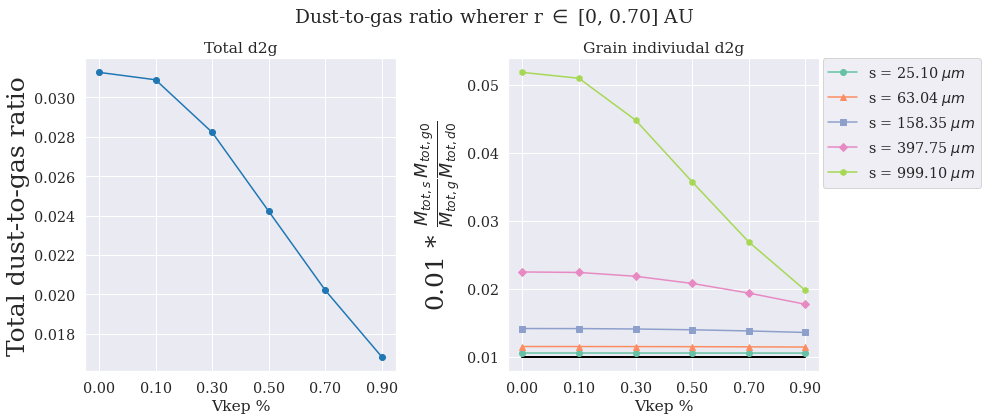

In [62]:
## > revap
smask    = (ss == ss_unique[-1])

idssort = np.argsort([np.float64(sq[:-3]) for sq in slisti ])
dm0 = sphere._M[1:,0]   -sphere._M[:-1,0]
dm  = sphere._M[1:,snap]-sphere._M[:-1,snap]
fig, (ax, ax1) = plt.subplots(1,2,figsize= (14,6))
d2glist   = [[],[],[],[],[]]
veplist   = []
dd2glist  = [] 
dd2g0list = []
for i,_ in enumerate(listi):
    rmask = (rca[i] < revap)
    dd2g  = np.sum(M_all[i][rmask]) / np.sum(dm[rmask])
    #dd2g0 = np.sum(M0a  [i][rmask]) / np.sum(dm[rmask])
    
    vkep  = filea[i][-7:-3]
    dd2glist .append(dd2g )
    #dd2g0list.append(dd2g0)
    veplist  .append(vkep )
    Mds    = Md[i]
    
    for si, sss in enumerate(slisti):
        d2gs   = np.sum(Mds [si][rmask])/np.sum(dm [rmask])
        ds2gs0 = np.sum(M0a[si][rmask])/np.sum(dm0[rmask])
        d2glist[si].append(0.01*d2gs/ds2gs0)
# for total d2g
#ax.plot(veplist,dd2glist, color = 'tab:blue',marker = 'o')
ax.plot(veplist,np.array(dd2glist), color = 'tab:blue',marker = 'o')

for idd, idsort in enumerate(idssort):
    ax1.plot(veplist, d2glist[idsort],shapeDict[idd], label = 's = %.2f'%(cm_to_microns(ss_unique[idd])) + ' $ \mu m$')
ax1.plot(veplist, 0.01*np.ones_like(veplist,dtype = np.float),lw = 2, color = 'black',zorder = 1)

ax.set_xlabel (r'Vkep %')
#ax.set_ylabel (r'Total dust-to-gas ratio')
ax .set_ylabel(r'Total dust-to-gas ratio', Fontsize = 25)
ax1.set_ylabel(r'0.01 * $\frac{M_{tot,s}}{M_{tot,g}} \frac{M_{tot,g0}}{M_{tot,d0}}$', Fontsize = 25)

ax1.set_xlabel(r'Vkep %')
#ax1.set_ylabel(r'0.01 * $\frac{M_{tot,s}}{M_{tot,g}} \frac{M_{tot,g0}}{M_{tot,d0}}$', Fontsize = 25)

ax.set_title('Total d2g')
ax1.set_title('Grain indiviudal d2g')

ax1.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', borderaxespad = 0.)

fig.suptitle('Dust-to-gas ratio wherer r $\in$ [0, %.2f] AU'%(revap/sc.CGS.AU))
fig.tight_layout()
fig.subplots_adjust(top=0.86)

CreateDir  ('./plots/'+listi[0][:6]+'/Binwise')
fig.savefig('./plots/'+listi[0][:6]+'/Binwise/1 less-revap.png')

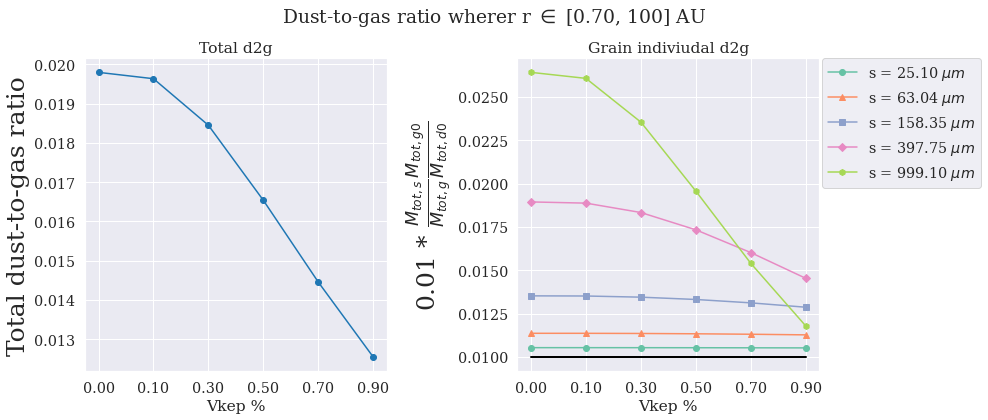

In [63]:
## > revap
smask    = (ss == ss_unique[-1])

idssort = np.argsort([np.float64(sq[:-3]) for sq in slisti ])
dm0 = sphere._M[1:,0]   -sphere._M[:-1,0]
dm  = sphere._M[1:,snap]-sphere._M[:-1,snap]
fig, (ax, ax1) = plt.subplots(1,2,figsize= (14,6))
d2glist   = [[],[],[],[],[]]
veplist   = []
dd2glist  = [] 
dd2g0list = []
for i,_ in enumerate(listi):
    rmask = (rca[i] > revap) & (rca[i]< 100*sc.CGS.AU)
    dd2g  = np.sum(M_all[i][rmask]) / np.sum(dm[rmask])
    #dd2g0 = np.sum(M0a  [i][rmask]) / np.sum(dm[rmask])
    
    vkep  = filea[i][-7:-3]
    dd2glist .append(dd2g )
    #dd2g0list.append(dd2g0)
    veplist  .append(vkep )
    Mds    = Md[i]
    
    for si, sss in enumerate(slisti):
        d2gs   = np.sum(Mds [si][rmask])/np.sum(dm [rmask])
        ds2gs0 = np.sum(M0a[si][rmask])/np.sum(dm0[rmask])
        d2glist[si].append(0.01*d2gs/ds2gs0)
# for total d2g
#ax.plot(veplist,dd2glist, color = 'tab:blue',marker = 'o')
ax.plot(veplist,np.array(dd2glist), color = 'tab:blue',marker = 'o')

for idd, idsort in enumerate(idssort):
    ax1.plot(veplist, d2glist[idsort],shapeDict[idd], label = 's = %.2f'%(cm_to_microns(ss_unique[idd])) + ' $ \mu m$')
ax1.plot(veplist, 0.01*np.ones_like(veplist,dtype = np.float),lw = 2, color = 'black',zorder = 1)

ax.set_xlabel (r'Vkep %')
#ax.set_ylabel (r'Total dust-to-gas ratio')

ax .set_ylabel(r'Total dust-to-gas ratio', Fontsize = 25)
ax1.set_ylabel(r'0.01 * $\frac{M_{tot,s}}{M_{tot,g}} \frac{M_{tot,g0}}{M_{tot,d0}}$', Fontsize = 25)

ax1.set_xlabel(r'Vkep %')
#ax1.set_ylabel(r'0.01 * $\frac{M_{tot,s}}{M_{tot,g}} \frac{M_{tot,g0}}{M_{tot,d0}}$', Fontsize = 25)

ax.set_title('Total d2g')
ax1.set_title('Grain indiviudal d2g')

ax1.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', borderaxespad = 0.)

fig.suptitle('Dust-to-gas ratio wherer r $\in$ [%.2f, 100] AU'%(revap/sc.CGS.AU))
fig.tight_layout()
fig.subplots_adjust(top=0.86)
fig.savefig('./plots/'+listi[0][:6]+'/Binwise/2 revap-100.png')

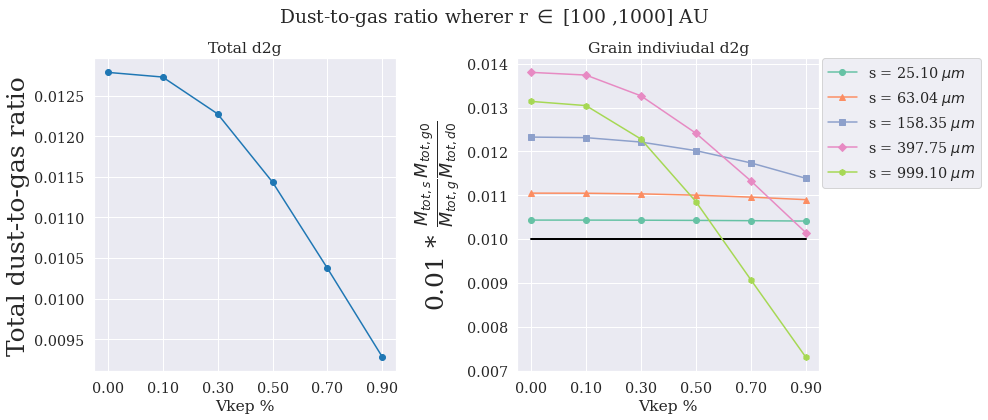

In [64]:
smask    = (ss == ss_unique[-1])

idssort = np.argsort([np.float64(sq[:-3]) for sq in slisti ])
dm0 = sphere._M[1:,0]   -sphere._M[:-1,0]
dm  = sphere._M[1:,snap]-sphere._M[:-1,snap]
fig, (ax, ax1) = plt.subplots(1,2,figsize= (14,6))
d2glist   = [[],[],[],[],[]]
veplist   = []
dd2glist  = [] 
dd2g0list = []
for i,_ in enumerate(listi):
    rmask =  (rca[i]> 100*sc.CGS.AU) & (rca[i]< 1000*sc.CGS.AU)
    dd2g  = np.sum(M_all[i][rmask]) / np.sum(dm[rmask])
    #dd2g0 = np.sum(M0a  [i][rmask]) / np.sum(dm[rmask])
    
    vkep  = filea[i][-7:-3]
    dd2glist .append(dd2g )
    #dd2g0list.append(dd2g0)
    veplist  .append(vkep )
    Mds    = Md[i]
    
    for si, sss in enumerate(slisti):
        d2gs   = np.sum(Mds [si][rmask])/np.sum(dm [rmask])
        ds2gs0 = np.sum(M0a[si][rmask])/np.sum(dm0[rmask])
        d2glist[si].append(0.01*d2gs/ds2gs0)
# for total d2g
#ax.plot(veplist,dd2glist, color = 'tab:blue',marker = 'o')
ax.plot(veplist,np.array(dd2glist), color = 'tab:blue',marker = 'o')

for idd, idsort in enumerate(idssort):
    ax1.plot(veplist, d2glist[idsort],shapeDict[idd], label = 's = %.2f'%(cm_to_microns(ss_unique[idd])) + ' $ \mu m$')
ax1.plot(veplist, 0.01*np.ones_like(veplist,dtype = np.float),lw = 2, color = 'black',zorder = 1)
ax.set_xlabel (r'Vkep %')
#ax.set_ylabel (r'Total dust-to-gas ratio')

ax .set_ylabel(r'Total dust-to-gas ratio', Fontsize = 25)
ax1.set_ylabel(r'0.01 * $\frac{M_{tot,s}}{M_{tot,g}} \frac{M_{tot,g0}}{M_{tot,d0}}$', Fontsize = 25)

ax1.set_xlabel(r'Vkep %')
#ax1.set_ylabel(r'0.01 * $\frac{M_{tot,s}}{M_{tot,g}} \frac{M_{tot,g0}}{M_{tot,d0}}$', Fontsize = 25)

ax.set_title('Total d2g')
ax1.set_title('Grain indiviudal d2g')

ax1.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', borderaxespad = 0.)

fig.suptitle('Dust-to-gas ratio wherer r $\in$ [100 ,1000] AU')
fig.tight_layout()
fig.subplots_adjust(top=0.86)
fig.savefig('./plots/'+listi[0][:6]+'/Binwise/3 100-1000.png')

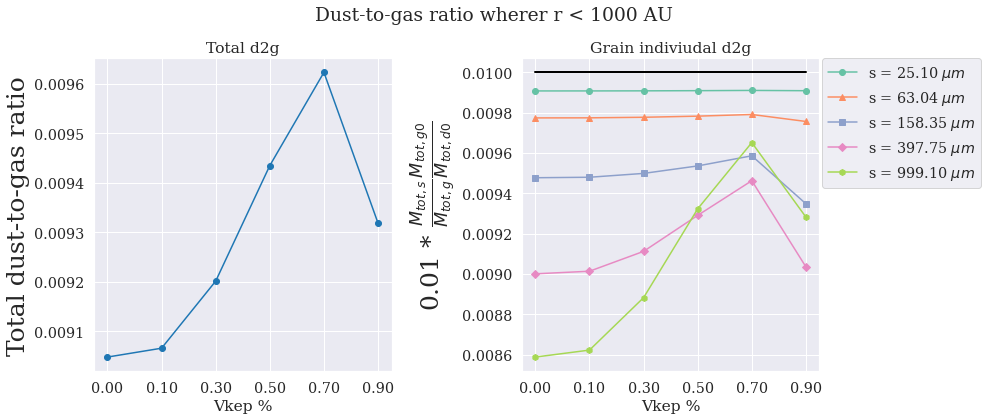

In [65]:
smask    = (ss == ss_unique[-1])

idssort = np.argsort([np.float64(sq[:-3]) for sq in slisti ])
dm0 = sphere._M[1:,0]   -sphere._M[:-1,0]
dm  = sphere._M[1:,snap]-sphere._M[:-1,snap]
fig, (ax, ax1) = plt.subplots(1,2,figsize= (14,6))
d2glist   = [[],[],[],[],[]]
veplist   = []
dd2glist  = [] 
dd2g0list = []
for i,_ in enumerate(listi):
    rmask = (rca[i] > 1000*sc.CGS.AU) 
    dd2g  = np.sum(M_all[i][rmask]) / np.sum(dm[rmask])
    #dd2g0 = np.sum(M0a  [i][rmask]) / np.sum(dm[rmask])
    
    vkep  = filea[i][-7:-3]
    dd2glist .append(dd2g )
    #dd2g0list.append(dd2g0)
    veplist  .append(vkep )
    Mds    = Md[i]
    
    for si, sss in enumerate(slisti):
        d2gs   = np.sum(Mds [si][rmask])/np.sum(dm [rmask])
        ds2gs0 = np.sum(M0a[si][rmask])/np.sum(dm0[rmask])
        d2glist[si].append(0.01*d2gs/ds2gs0)
# for total d2g
#ax.plot(veplist,dd2glist, color = 'tab:blue',marker = 'o')
ax.plot(veplist,np.array(dd2glist), color = 'tab:blue',marker = 'o')

for idd, idsort in enumerate(idssort):
    ax1.plot(veplist, d2glist[idsort],shapeDict[idd], label = 's = %.2f'%(cm_to_microns(ss_unique[idd])) + ' $ \mu m$')
ax1.plot(veplist, 0.01*np.ones_like(veplist,dtype = np.float),lw = 2, color = 'black',zorder = 1)
ax.set_xlabel (r'Vkep %')
#ax.set_ylabel (r'Total dust-to-gas ratio')

ax .set_ylabel(r'Total dust-to-gas ratio', Fontsize = 25)
ax1.set_ylabel(r'0.01 * $\frac{M_{tot,s}}{M_{tot,g}} \frac{M_{tot,g0}}{M_{tot,d0}}$', Fontsize = 25)

ax1.set_xlabel(r'Vkep %')
#ax1.set_ylabel(r'0.01 * $\frac{M_{tot,s}}{M_{tot,g}} \frac{M_{tot,g0}}{M_{tot,d0}}$', Fontsize = 25)

ax.set_title('Total d2g')
ax1.set_title('Grain indiviudal d2g')

ax1.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', borderaxespad = 0.)

fig.suptitle('Dust-to-gas ratio wherer r < 1000 AU')
fig.tight_layout()
fig.subplots_adjust(top=0.86)
fig.savefig('./plots/'+listi[0][:6]+'/Binwise/4 larger-1000.png')

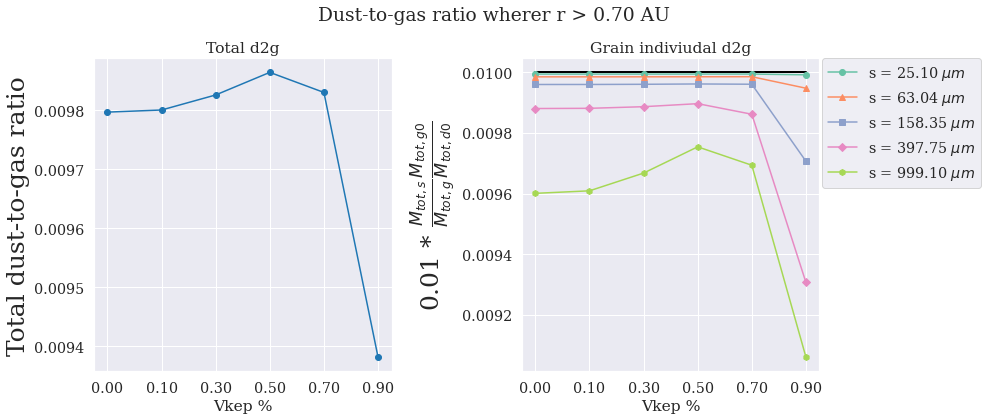

In [66]:
smask    = (ss == ss_unique[-1])

idssort = np.argsort([np.float64(sq[:-3]) for sq in slisti ])
dm0 = sphere._M[1:,0]   -sphere._M[:-1,0]
dm  = sphere._M[1:,snap]-sphere._M[:-1,snap]
fig, (ax, ax1) = plt.subplots(1,2,figsize= (14,6))
d2glist   = [[],[],[],[],[]]
veplist   = []
dd2glist  = [] 
dd2g0list = []
for i,_ in enumerate(listi):
    rmask = (rca[i] > revap)
    dd2g  = np.sum(M_all[i][rmask]) / np.sum(dm[rmask])
    #dd2g0 = np.sum(M0a  [i][rmask]) / np.sum(dm[rmask])
    
    vkep  = filea[i][-7:-3]
    dd2glist .append(dd2g )
    #dd2g0list.append(dd2g0)
    veplist  .append(vkep )
    Mds    = Md[i]
    
    for si, sss in enumerate(slisti):
        d2gs   = np.sum(Mds [si][rmask])/np.sum(dm [rmask])
        ds2gs0 = np.sum(M0a[si][rmask])/np.sum(dm0[rmask])
        d2glist[si].append(0.01*d2gs/ds2gs0)
# for total d2g
#ax.plot(veplist,dd2glist, color = 'tab:blue',marker = 'o')
ax.plot(veplist,np.array(dd2glist), color = 'tab:blue',marker = 'o')

for idd, idsort in enumerate(idssort):
    ax1.plot(veplist, d2glist[idsort],shapeDict[idd], label = 's = %.2f'%(cm_to_microns(ss_unique[idd])) + ' $ \mu m$')
ax1.plot(veplist, 0.01*np.ones_like(veplist,dtype = np.float),lw = 2, color = 'black',zorder = 1)

ax.set_xlabel (r'Vkep %')
#ax.set_ylabel (r'Total dust-to-gas ratio')

ax .set_ylabel(r'Total dust-to-gas ratio', Fontsize = 25)
ax1.set_ylabel(r'0.01 * $\frac{M_{tot,s}}{M_{tot,g}} \frac{M_{tot,g0}}{M_{tot,d0}}$', Fontsize = 25)

ax1.set_xlabel(r'Vkep %')
#ax1.set_ylabel(r'0.01 * $\frac{M_{tot,s}}{M_{tot,g}} \frac{M_{tot,g0}}{M_{tot,d0}}$', Fontsize = 25)

ax.set_title('Total d2g')
ax1.set_title('Grain indiviudal d2g')

ax1.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', borderaxespad = 0.)

fig.suptitle('Dust-to-gas ratio wherer r > %.2f AU'%(revap/sc.CGS.AU))
fig.tight_layout()
fig.subplots_adjust(top=0.86)
fig.savefig('./plots/'+listi[0][:6]+'/Binwise/5 larger-revap.png')

In [4]:
listi = [
         #'run006_large_Grains_4_pr_5bins_1000_0.00kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.10kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.30kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.50kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.70kep',
         #'run006_large_Grains_4_pr_5bins_1000_0.90kep',
       ####
         #'run038_large_Grains_4_pr_5bins_1000_0.00kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.10kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.30kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.50kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.70kep',
         #'run038_large_Grains_4_pr_5bins_1000_0.90kep',
       ####
         #'run067_large_Grains_4_pr_5bins_1000_0.00kep',
         'run067_large_Grains_4_pr_5bins_1000_0.10kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.30kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.50kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.70kep',
         #'run067_large_Grains_4_pr_5bins_1000_0.90kep',
       ####     
         #'run069_large_Grains_4_pr_5bins_1000_0.00kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.10kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.30kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.50kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.70kep',
         #'run069_large_Grains_4_pr_5bins_1000_0.90kep'
        ]

file = listi[0]
ss = np.loadtxt('../simData/' + file +'/s.txt', max_rows=  1) ; print("\t ss Done" )
x  = np.loadtxt('../simData/' + file +'/x.txt' )              ; print("\t  x Done" )
y  = np.loadtxt('../simData/' + file +'/y.txt' )              ; print("\t  y Done" )
vx = np.loadtxt('../simData/' + file +'/vx.txt')              ; print("\t vx Done")
vy = np.loadtxt('../simData/' + file +'/vy.txt')              ; print("\t vy Done")
St = np.loadtxt('../simData/' + file +'/St.txt')              ; print("\t Stokes Done")
t  = np.loadtxt('../simData/' + file +'/time.txt')             ; print('\t time done')
#pm = np.loadtxt('../simData/' + file +'/mass.txt')           ; print("\t mass done" )
r  = radius(x,y)                                              ; print("\t  r Done" )
vr, vphi = cartisian_to_polar_velocity(x,y,r,vx,vy)           ; print("\t Polar done")

s_unique = np.unique(ss)
smask    = (ss == s_unique[-2])

dataPath = './DATA2/'

print("all done")

	 ss Done
	  x Done
	  y Done
	 vx Done
	 vy Done
	 Stokes Done
	 time done
	  r Done
	 Polar done
all done


In [367]:
s_unique = np.unique(ss)
smask    = (ss == s_unique[-2])

In [229]:
St = np.loadtxt('../simData/' + file +'/St.txt')              ; print("\t Stokes Done")

	 Stokes Done


(-50.0, 50.0)

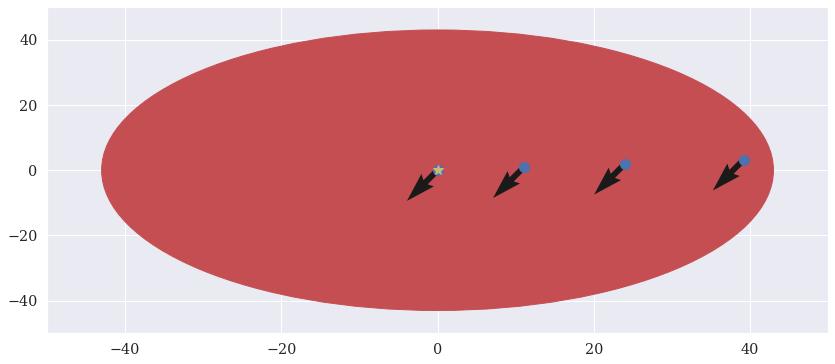

In [368]:
idx = 29
ii = 800
fig, ax = plt.subplots(figsize = (14,6)) 
circle1 = plt.Circle((0, 0), 43, color='r', zorder = 1)
ax.add_patch(circle1)
plt.quiver(x[idx, smask][::ii]/sc.CGS.AU, y[idx, smask][::ii]/sc.CGS.AU, 
           vx[idx, smask][::ii]/np.abs(vx[idx, smask][::ii]), vy[idx, smask][::ii]/np.abs(vy[idx, smask][::ii]),
           zorder = 2)
plt.plot(x[idx, smask][::ii]/sc.CGS.AU,y[idx, smask][::ii]/sc.CGS.AU,'bo', ms = 10)
plt.plot(0, 0,'y*', ms = 10)
plt.xlim([-50, 50])
plt.ylim([-50, 50])

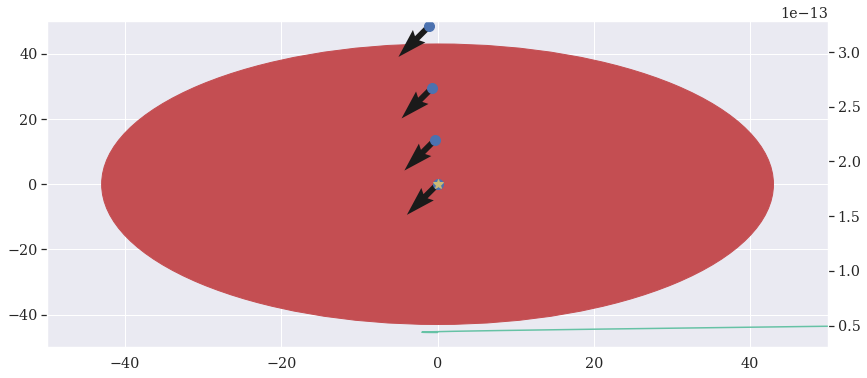

In [365]:
idx = 28
ii = 800
fig, ax = plt.subplots(figsize = (14,6)) 
circle1 = plt.Circle((0, 0), 43, color='r', zorder = 1)
ax.add_patch(circle1)
plt.quiver(x[idx, smask][::ii]/sc.CGS.AU, y[idx, smask][::ii]/sc.CGS.AU, 
           vx[idx, smask][::ii]/np.abs(vx[idx, smask][::ii]), vy[idx, smask][::ii]/np.abs(vy[idx, smask][::ii]),
           zorder = 2)
plt.plot(x[idx, smask][::ii]/sc.CGS.AU,y[idx, smask][::ii]/sc.CGS.AU,'bo', ms = 10)
r[idx, smask][::ii][St[idx, smask][::ii] < 1]

plt.plot(0, 0,'y*', ms = 10)
plt.xlim([-50, 50])
plt.ylim([-50, 50])

ax1 = ax.twinx()
ax1.plot(x[idx, smask][::ii]/sc.CGS.AU, St[idx, smask][::ii]/sc.CGS.AU)
ax1.grid(False)

In [363]:
r[idx, smask][::ii][St[idx, smask][::ii] < 1].max()/sc.CGS.AU

1375.5571789387575

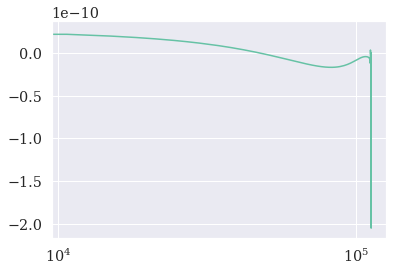

In [212]:
plt.plot(t[:, smask][:,5*ii]/sc.CGS.yr,vy[:, smask][:,5*ii]/sc.CGS.AU)
plt.xscale('log')

In [217]:
"%.2e"%(sphere.t[20]/sc.CGS.yr)

'2.71e+04'

(-100.0, 100.0)

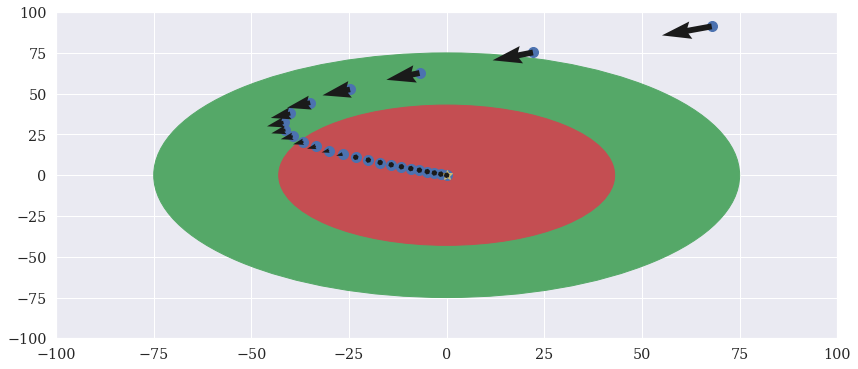

In [358]:
idx = 31
ii = 500
fig, ax = plt.subplots(figsize = (14,6)) 
circle1 = plt.Circle((0, 0), 43, color='r', zorder = 2)
ax.add_patch(circle1)
circle1 = plt.Circle((0, 0), 75, color='g', zorder = 1)
ax.add_patch(circle1)

plt.quiver(x[idx, smask][::ii]/sc.CGS.AU, y[idx, smask][::ii]/sc.CGS.AU, 
           vx[idx, smask][::ii]#/np.abs(vx[idx, smask][::ii])
           , 
           vy[idx, smask][::ii]#/np.abs(vy[idx, smask][::ii])
           ,
           zorder = 3)
#plt.plot(x[idx-1, smask][::ii]/sc.CGS.AU,y[idx-1, smask][::ii]/sc.CGS.AU,'go', ms = 10)
#plt.plot(x[idx+1, smask][::ii]/sc.CGS.AU,y[idx+1, smask][::ii]/sc.CGS.AU,'ro', ms = 10)
plt.plot(x[idx, smask][::ii]/sc.CGS.AU,y[idx, smask][::ii]/sc.CGS.AU,'bo', ms = 10)

plt.plot(0, 0,'y*', ms = 10)
#plt.xlim([-1e-3, 1e-3])
#plt.ylim([-1e-3, 1e-3])

plt.xlim([-100, 100])
plt.ylim([-100, 100])

#ax1 = ax.twinx()
#plt.scatter(x[idx, smask][::ii]/sc.CGS.AU,y[idx, smask][::ii]/sc.CGS.AU, c=St[idx, smask][::ii], s=500)


(-100.0, 100.0)

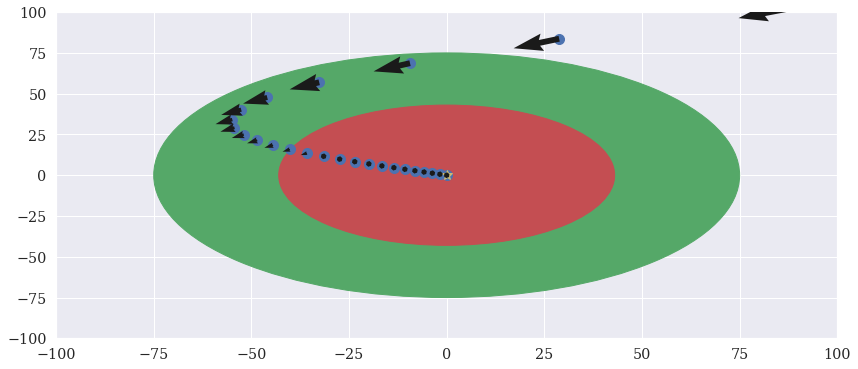

In [359]:
idx = 32
ii = 500
fig, ax = plt.subplots(figsize = (14,6)) 
circle1 = plt.Circle((0, 0), 43, color='r', zorder = 2)
ax.add_patch(circle1)
circle1 = plt.Circle((0, 0), 75, color='g', zorder = 1)
ax.add_patch(circle1)

plt.quiver(x[idx, smask][::ii]/sc.CGS.AU, y[idx, smask][::ii]/sc.CGS.AU, 
           vx[idx, smask][::ii]#/np.abs(vx[idx, smask][::ii])
           , 
           vy[idx, smask][::ii]#/np.abs(vy[idx, smask][::ii])
           ,
           zorder = 3)
#plt.plot(x[idx-1, smask][::ii]/sc.CGS.AU,y[idx-1, smask][::ii]/sc.CGS.AU,'go', ms = 10)
#plt.plot(x[idx+1, smask][::ii]/sc.CGS.AU,y[idx+1, smask][::ii]/sc.CGS.AU,'ro', ms = 10)
plt.plot(x[idx, smask][::ii]/sc.CGS.AU,y[idx, smask][::ii]/sc.CGS.AU,'bo', ms = 10)

plt.plot(0, 0,'y*', ms = 10)
#plt.xlim([-1e-3, 1e-3])
#plt.ylim([-1e-3, 1e-3])

plt.xlim([-100, 100])
plt.ylim([-100, 100])

#ax1 = ax.twinx()
#plt.scatter(x[idx, smask][::ii]/sc.CGS.AU,y[idx, smask][::ii]/sc.CGS.AU, c=St[idx, smask][::ii], s=500)


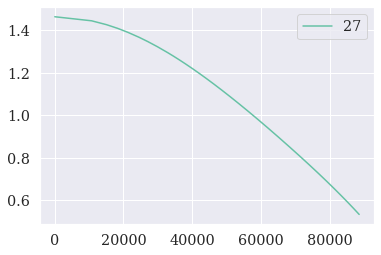

In [349]:
ii =6500
plt.plot(t[:33,  smask][:,ii]/sc.CGS.yr , St[:33, smask][:,ii]  , label =  idx ) 
#plt.plot(x[:, smask][:,ii]/sc.CGS.AU,y[:, smask][:,ii]/sc.CGS.AU, label =  idx2)
#plt.plot(x[:, smask][:,ii]/sc.CGS.AU,y[:, smask][:,ii]/sc.CGS.AU, label =  idx3)

plt.legend()
#plt.jet()
#plt.colorbar()

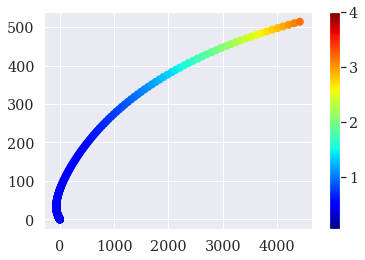

In [333]:
idx = 33
plt.scatter(x[idx, smask][::ii]/sc.CGS.AU,y[idx, smask][::ii]/sc.CGS.AU, c=St[idx, smask][::ii], s=50,vmin=0.05, vmax=4)
plt.jet()
plt.colorbar()

(-100.0, 100.0)

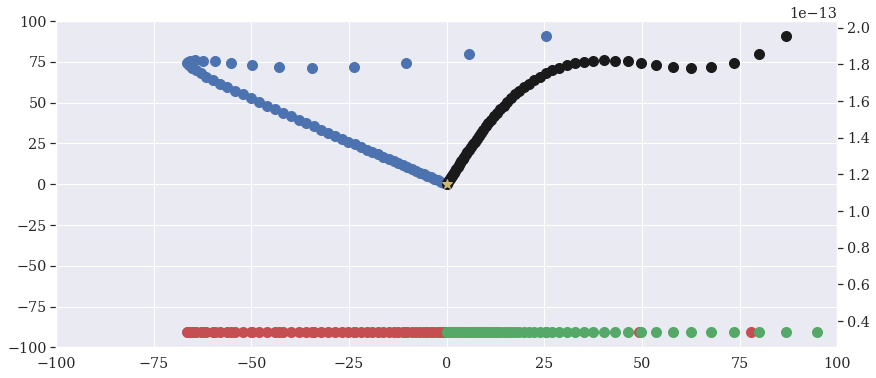

In [280]:
idx = 33
ii = 200
fig, ax = plt.subplots(figsize = (14,6)) 

ax1 = ax.twinx()
ax1.grid(False)

ax.plot(x[idx, smask][::ii]/sc.CGS.AU,r[idx, smask][::ii]/sc.CGS.AU,'bo', ms = 10)
ax.plot(y[idx, smask][::ii]/sc.CGS.AU,r[idx, smask][::ii]/sc.CGS.AU,'ko', ms = 10)

ax1.plot(x[idx, smask][::ii]/sc.CGS.AU,St[idx, smask][::ii]/sc.CGS.AU,'ro', ms = 10)
ax1.plot(y[idx, smask][::ii]/sc.CGS.AU,St[idx, smask][::ii]/sc.CGS.AU,'go', ms = 10)


ax.plot(0, 0,'y*', ms = 10)
ax.set_xlim([-100, 100])
ax.set_ylim([-100, 100])

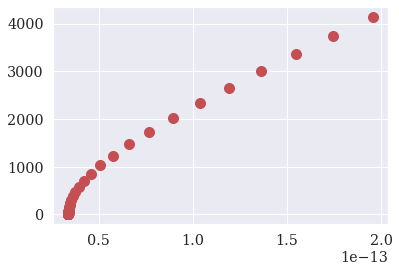

In [283]:
plt.plot(St[idx, smask][::ii]/sc.CGS.AU,r[idx, smask][::ii]/sc.CGS.AU,'ro', ms = 10)


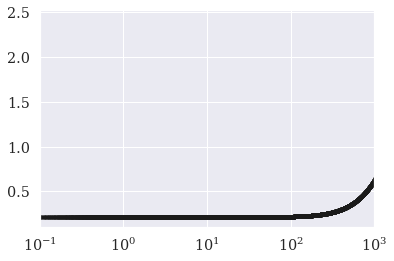

In [232]:
idx = 50


plt.plot(r[idx, smask]/sc.CGS.AU,St[idx, smask],'ko', ms = 3)
#plt.vlines(43,-20000,np.max(vr[idx, smask]),color = 'tab:red')
plt.xlim([1e-1,1000])
plt.xscale('log')

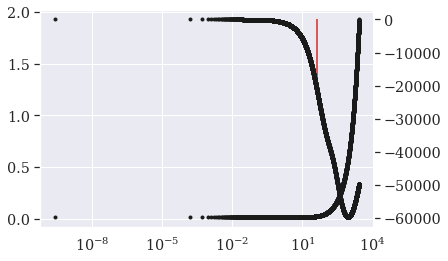

In [249]:
idx = 100

fig,ax = plt.subplots()
ax1 = ax.twinx()
ax.plot(r[idx, smask]/sc.CGS.AU,St[idx, smask],'ko', ms = 3)
#ax.vlines(43,-20000,np.max(vr[idx, smask]),color = 'tab:red')
#ax.set_xlim([1e-1,5000])
ax1.grid(False)


ax1.plot(r[idx, smask]/sc.CGS.AU,vr[idx, smask],'ko', ms = 3)
ax1.vlines(43,-20000,np.max(vr[idx, smask]),color = 'tab:red')
ax1.set_xscale('log')

ax1.set_xscale('log')

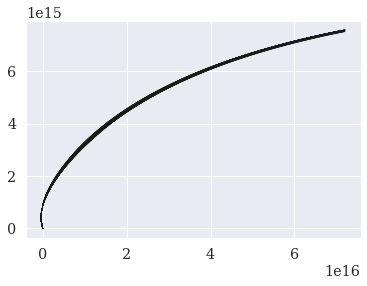

In [109]:
plt.quiver(x[idx, smask], y[idx, smask], vr[idx, smask], vphi[idx, smask])

In [105]:
np.c_[x[idx, smask], y[idx, smask]]

array([[-1.99407571e+10,  8.96822194e+09],
       [-5.30000103e+10,  3.00562744e+10],
       [-8.59859457e+10,  5.11398599e+10],
       ...,
       [ 7.20917334e+16,  7.53880626e+15],
       [ 7.21219359e+16,  7.53977859e+15],
       [ 7.21521375e+16,  7.54075055e+15]])

In [106]:
x[idx, smask]

array([-1.99407571e+10, -5.30000103e+10, -8.59859457e+10, ...,
        7.20917334e+16,  7.21219359e+16,  7.21521375e+16])

In [107]:
y[idx, smask]

array([8.96822194e+09, 3.00562744e+10, 5.11398599e+10, ...,
       7.53880626e+15, 7.53977859e+15, 7.54075055e+15])

In [104]:
x[idx, smask].shape

(16380,)

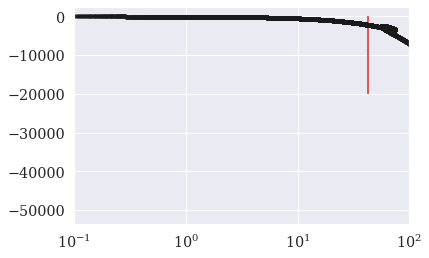

In [227]:
idx = 50


plt.plot(r[idx, smask]/sc.CGS.AU,vr[idx, smask],'ko', ms = 3)
plt.vlines(43,-20000,np.max(vr[idx, smask]),color = 'tab:red')
plt.xlim([1e-1,100])
plt.xscale('log')

In [69]:
x.shape

(814, 81900)

In [ ]:
ax = plt.subplot(111)
plt.plot(r[30, smask]/sc.CGS.AU ,vphi[30, smask])
plt.plot(r[30, smask]/sc.CGS.AU ,vr[30, smask])

ax1 = ax.twinx()
ax1.plot(r[30, smask]/sc.CGS.AU ,St[30, smask], color = 'black')
ax1.grid(False)


#ax1.vlines(45,dust2g.min(),dust2g.max())
ax1.vlines(40,dust2g.min(),dust2g.max())
ax1.vlines(50,dust2g.min(),dust2g.max())


plt.xscale('log')

In [ ]:
plt.plot(x[:30, smask][:,rmask]/sc.CGS.AU ,y[:30,smask][:,rmask]/sc.CGS.AU)
plt.xlim([-50,50])
plt.show()

In [ ]:
plt.plot(x[27, smask][nprmask]/sc.CGS.AU ,y[27,smask][np.invert(rmask)]/sc.CGS.AU)

In [ ]:
plt.plot(x[snap, smask][np.invert(rmask)]/sc.CGS.AU ,y[snap,smask][np.invert(rmask)]/sc.CGS.AU,'o')


In [ ]:
fig, (ax, ax1) = plt.subplots(2,1, figsize = (9,8))
snap = 60

rmask = (r[snap, smask]/sc.CGS.AU >40)  & (r[snap, smask]/sc.CGS.AU <50) 


ax.plot(x[snap, smask][rmask]/sc.CGS.AU ,y[snap,smask][rmask]/sc.CGS.AU,'o')
cir  = plt.Circle((0,0),40,zorder=  1, color = 'tab:blue')
cir1 = plt.Circle((0,0),50,zorder=  1, color = 'tab:red')

ax.set_title('Number of particles, percent of total: %.3e  %.3f'%(np.sum(rmask), np.sum(rmask)/len(rmask)*100))

ax.add_patch(cir1)
ax.set_xlim([-50,50])
ax.set_ylim([-50,50])
ax.add_patch(cir)
ax1.set_title("Mass in area, procent of total: "%( np.sum(pm[snap,smask][rmask]), np.sum(pm[snap,smask][rmask])/np.sum(pm[snap,smask]) ) )
ax1.plot(r[snap, smask][rmask]/sc.CGS.AU ,pm[snap,smask][rmask]/sc.CGS.AU,'o')


plt.show()

In [ ]:
fig, (ax, ax1) = plt.subplots(2,1, figsize = (9,8))
snap = 29

rmask = (r[snap, smask]/sc.CGS.AU >40)  & (r[snap, smask]/sc.CGS.AU <50) 


ax.plot(x[snap, smask][rmask]/sc.CGS.AU ,y[snap,smask][rmask]/sc.CGS.AU,'o')
cir  = plt.Circle((0,0),40,zorder=  1, color = 'tab:blue')
cir1 = plt.Circle((0,0),50,zorder=  1, color = 'tab:red')

ax.set_title('Number of particles, percent of total: %.3e  %.3f'%(np.sum(rmask), np.sum(rmask)/len(rmask)*100))

ax.add_patch(cir1)
ax.set_xlim([-50,50])
ax.set_ylim([-50,50])
ax.add_patch(cir)
ax1.set_title('Number of particles, percent of total: %.3e  %.3f'%(np.sum(pm[snap,smask][rmask]), 
                                                                  np.sum(pm[snap,smask][rmask])/np.sum(pm[snap,smask])*100))
ax1.plot(r[snap, smask][rmask]/sc.CGS.AU ,pm[snap,smask][rmask]/sc.CGS.AU,'o')


plt.show()

In [ ]:
fig, (ax, ax1) = plt.subplots(2,1, figsize = (9,8))
snap = 30

rmask = (r[snap, smask]/sc.CGS.AU >40)  & (r[snap, smask]/sc.CGS.AU <50) 


ax.plot(x[snap, smask][rmask]/sc.CGS.AU ,y[snap,smask][rmask]/sc.CGS.AU,'o')
cir  = plt.Circle((0,0),40,zorder=  1, color = 'tab:blue')
cir1 = plt.Circle((0,0),50,zorder=  1, color = 'tab:red')

ax.set_title('Number of particles, percent of total: %.3e  %.3f'%(np.sum(rmask), np.sum(rmask)/len(rmask)*100))

ax.add_patch(cir1)
ax.set_xlim([-50,50])
ax.set_ylim([-50,50])
ax.add_patch(cir)
ax1.set_title('Number of particles, percent of total: %.3e  %.3f'%(np.sum(pm[snap,smask][rmask]), 
                                                                  np.sum(pm[snap,smask][rmask])/np.sum(pm[snap,smask])*100))
ax1.plot(r[snap, smask][rmask]/sc.CGS.AU ,pm[snap,smask][rmask]/sc.CGS.AU,'o')


plt.show()

In [ ]:
'Number of particles, percent of total: %.2e'%(1)

In [ ]:
'Number of particles, % of total: %.2e  %.2f'%(np.sum(rmask), np.sum(rmask)/len(rmask))

In [ ]:
np.sum(rmask)

In [ ]:
rmask

In [ ]:
ax = plt.subplot(111)
plt.plot(x[:30, smask][:,rmask]/sc.CGS.AU ,y[:30,smask][:,rmask]/sc.CGS.AU)
cir  = plt.Circle((0,0),40,zorder=  1, color = 'tab:blue')
cir1 = plt.Circle((0,0),50,zorder=  1, color = 'tab:red')

ax.add_patch(cir1)

ax.add_patch(cir)
plt.xlim([-50,50])
plt.show()

In [ ]:
file = listi[1]
print(file)

In [ ]:
fig, ax = plt.subplots()
snap = 28
rc, dust2g, _, _ ,_   = np.loadtxt(dataPath + file + '/Snap%i/'%(snap)+'9.99098e-02_cm'+'/d2g.txt', 
                                                  unpack = True, skiprows = 2 ,  max_rows = None)
ax.plot(rc/sc.CGS.AU,dust2g)
snap = 29
rc, dust2g, _, _ ,_   = np.loadtxt(dataPath + file + '/Snap%i/'%(snap)+'9.99098e-02_cm'+'/d2g.txt', 
                                                  unpack = True, skiprows = 2 ,  max_rows = None)
ax.plot(rc/sc.CGS.AU,dust2g)

snap = 30
rc, dust2g, _, _ ,_   = np.loadtxt(dataPath + file + '/Snap%i/'%(snap)+'9.99098e-02_cm'+'/d2g.txt', 
                                                  unpack = True, skiprows = 2 ,  max_rows = None)
ax.plot(rc/sc.CGS.AU,dust2g)

ax.loglog()

In [ ]:
snap = 28

dm = sphere._M[1:,snap]- sphere._M[:-1,snap]
plt.plot(sphere._rc[:-1,snap]/sc.CGS.AU, dm)
snap = 29
dm = sphere._M[1:,snap]- sphere._M[:-1,snap]
plt.plot(sphere._rc[:-1,snap]/sc.CGS.AU, dm)
snap = 30
dm = sphere._M[1:,snap]- sphere._M[:-1,snap]
plt.plot(sphere._rc[:-1,snap]/sc.CGS.AU, dm)
plt.loglog()

In [ ]:
snap = 30

fig, (ax,ax1) = plt.subplots(1,2, figsize = (14,4))

ax .plot(r[snap, smask]/sc.CGS.AU ,pm[snap,smask],'.')
ax .plot(r[snap+1, smask]/sc.CGS.AU ,pm[snap+1,smask],'.')
ax .plot(r[snap+2, smask]/sc.CGS.AU ,pm[snap+2,smask],'.')
ax .loglog()

ax1.plot(r[snap, smask]  /sc.CGS.AU ,St[snap  ,smask],'.')
ax1.plot(r[snap+1, smask]/sc.CGS.AU ,St[snap+1,smask],'.')
ax1.plot(r[snap+2, smask]/sc.CGS.AU ,St[snap+2,smask],'.')
ax1.set_xscale('log')

In [ ]:
snap = 45
plt.plot(r[snap, smask]  /sc.CGS.AU ,St[snap,smask]/sc.CGS.AU,'.')
plt.plot(r[snap+1, smask]/sc.CGS.AU ,St[snap+1,smask]/sc.CGS.AU,'.')
plt.plot(r[snap+2, smask]/sc.CGS.AU ,St[snap+2,smask]/sc.CGS.AU,'.')
plt.xscale('log')

In [ ]:
St

In [ ]:
snap = 28
ax= plt.subplot(111)
dm = sphere._M[1:,snap]- sphere._M[:-1,snap]
plt.plot(sphere._rc[:-1,snap]/sc.CGS.AU, dm, color = 'tab:red')
ax1 = ax.twinx()

ax1.plot(r[snap, smask]/sc.CGS.AU ,pm[snap,smask]/sc.CGS.AU,'o')
ax1.loglog()
ax.set_yscale('log')
ax1.grid(False)

In [ ]:
snap = 29
ax= plt.subplot(111)
dm = sphere._M[1:,snap]- sphere._M[:-1,snap]
plt.plot(sphere._rc[:-1,snap]/sc.CGS.AU, dm, color = 'tab:red')
ax1 = ax.twinx()

ax1.plot(r[snap, smask]/sc.CGS.AU ,pm[snap,smask]/sc.CGS.AU,'o')
ax1.loglog()
ax.set_yscale('log')
ax1.grid(False)

In [ ]:
snap = 30
ax= plt.subplot(111)
dm = sphere._M[1:,snap]- sphere._M[:-1,snap]
plt.plot(sphere._rc[:-1,snap]/sc.CGS.AU, dm, color = 'tab:red')
ax1 = ax.twinx()

ax1.plot(r[snap, smask]/sc.CGS.AU ,pm[snap,smask]/sc.CGS.AU,'o')
ax1.loglog()
ax.set_yscale('log')
ax1.grid(False)

In [ ]:
os.listdir('run067')

In [ ]:
fopr
rc, dust2g, _, _ ,_   = np.loadtxt(dataPath + file + '/Snap%i/'%(snap)+'9.99098e-02_cm'+'/d2g.txt', 
                                              unpack = True, skiprows = 2 ,  max_rows = None)

In [ ]:
vc = np.array([ vx[30,smask][rmask][0], vy[30,smask][rmask][0]])

In [ ]:
A = np.array([
               [x[30,smask][rmask][0]/r[30,smask][rmask][0], -y[30,smask][rmask][0]/r[30,smask][rmask][0]],
               [y[30,smask][rmask][0]/r[30,smask][rmask][0], x[30,smask][rmask][0]/r[30,smask][rmask][0]]
             ])

In [ ]:
np.linalg.solve(A,vc)

In [ ]:
A

In [ ]:
vy[30, smask]

In [ ]:
plt.plot(r[30, smask][rmask], vr[30, smask][rmask])

In [ ]:
plt.plot( r[30, smask][rmask]/sc.CGS.AU, vr[30, smask][rmask] )

In [ ]:
plt.plot( r[30, smask][rmask]/sc.CGS.AU, x[30, smask][rmask]/sc.CGS.AU )

In [ ]:
plt.plot(x[30, smask],vr[30, smask])

In [ ]:
r[30, smask].shape

In [ ]:
plt.figure(figsize = (14,6))
ida = 9000
ax = plt.subplot(111)
ax.plot(x[:30, smask][:,ida]/sc.CGS.AU,vx[:30, smask][:,ida])
ax1 = ax.twinx()
ax1.plot(x[:30, smask][:,ida]/sc.CGS.AU,St[:30, smask][:,ida])

ax1.grid(False)
#plt.xlim([1e1,1e2])
ax1.vlines(1e1,1,5, zorder = 1)
ax1.vlines(1e2,1,5, zorder = 1)
ax1.vlines(45,1,5, zorder = 1)
plt.xscale('log')

In [ ]:
plt.plot(x[27, smask]/sc.CGS.AU,St[27, smask])
#plt.xlim([1e1,1e2])
plt.xscale('log')


In [ ]:
St

In [ ]:
idx = 3500

plt.plot(x[27, smask]/sc.CGS.AU,np.abs(vx[27, smask]))
plt.plot(x[28, smask]/sc.CGS.AU,np.abs(vx[28, smask]), color = 'tab:red')
plt.plot(sphere._rc[:,28]/sc.CGS.AU, np.abs(sphere._vg[:,28]), color = 'tab:blue')
plt.plot(np.abs(x[27, smask][idx])/sc.CGS.AU,np.abs(vx[27, smask][idx]), color = 'k',marker ='o' ,ms = 8)
plt.plot(np.abs(x[28, smask][idx])/sc.CGS.AU,np.abs(vx[28, smask][idx]), color = 'k',marker ='o' ,ms = 8)
plt.xscale('log')

In [ ]:
ax = plt.subplot(111)
idx = 60
ida = 50
plt.scatter(x[idx, smask][::ida]/sc.CGS.AU,y[idx, smask][::ida]/sc.CGS.AU,zorder = 3,color = 'k')
plt.scatter(x[idx-1, smask][::ida]/sc.CGS.AU,y[idx-1, smask][::ida]/sc.CGS.AU,zorder = 2, color = 'white')

cir  = plt.Circle((0,0),40,zorder=  1, color = 'tab:blue')
cir1 = plt.Circle((0,0),50,zorder=  1, color = 'tab:red')

ax.add_patch(cir1)

ax.add_patch(cir)
plt.xlim([-60,60])
plt.ylim([0,60])

In [ ]:
idx = 10500
ax = plt.subplot(111)
ax.plot(x[:31, smask][:,idx]/sc.CGS.AU ,y[:31, smask][:,idx]/sc.CGS.AU,'o')
plt.loglog()

In [ ]:
np.sum( (r[30, smask]/sc.CGS.AU >10) & (r[30, smask]/sc.CGS.AU <100) )

In [ ]:
r.shape

In [ ]:
listi = [
         'run067_large_Grains_4_pr_5bins_1000_0.00kep',
         'run067_large_Grains_4_pr_5bins_1000_0.10kep',
         'run067_large_Grains_4_pr_5bins_1000_0.30kep',
         'run067_large_Grains_4_pr_5bins_1000_0.50kep',
         'run067_large_Grains_4_pr_5bins_1000_0.70kep',
         'run067_large_Grains_4_pr_5bins_1000_0.90kep',
        ]

In [ ]:
ax = plt.subplot(111)
ax.plot(sphere.t[:31]/sc.CGS.yr ,r[:31, smask][:,idx]/sc.CGS.AU)
ax1 = ax.twinx()
ax1.plot(sphere.t[:31]/sc.CGS.yr ,St[:31, smask][:,idx], color = "tab:blue")
ax1.grid(False)
ax.set_ylim([1e1,1e2])
ax.set_yscale('log')

In [ ]:
ax = plt.subplot(111)
ax.plot(sphere.t[:31]/sc.CGS.yr ,np.abs(vr[:31, smask][:,idx]))
ax.plot(sphere.t[:31]/sc.CGS.yr ,vphi[:31, smask][:,idx])
#ax.set_xscale('log')

In [ ]:
ax = plt.subplot(111)
ax.plot(sphere.t[:31]/sc.CGS.yr ,x[:31, smask][:,idx]/sc.CGS.AU)
ax.plot(sphere.t[:31]/sc.CGS.yr ,y[:31, smask][:,idx]/sc.CGS.AU)
ax.plot(sphere.t[:31]/sc.CGS.yr ,r[:31, smask][:,idx]/sc.CGS.AU)
#ax.set_xscale('log')
plt.yscale('log')

In [ ]:
vr[:31, smask][:,idx]

In [ ]:
St.shape

In [ ]:
sphere.t[27:].shape, x[27:, smask][:,idx].shape

In [ ]:
x[28, smask].shape

In [ ]:
sphere.dt[28]

In [ ]:
5000*63988414090.15967/sc.CGS.AU

In [ ]:
x[28, smask][10000]

In [ ]:
plt.plot(x[27, smask]/sc.CGS.AU, St[27,smask])
plt.plot(x[28, smask]/sc.CGS.AU, St[28,smask])
plt.xscale('log')

In [ ]:
plt.plot(sphere._rc[:,27]/sc.CGS.AU, sphere._vg[:,27])
plt.plot(sphere._rc[:,28]/sc.CGS.AU, sphere._vg[:,28], color = 'tab:red')

In [ ]:
plt.plot(x[idsnap_1, smask],pm[idsnap_1, smask])
plt.plot(x[idsnap_2, smask],pm[idsnap_2, smask])


In [ ]:
fig, (ax1, ax2) = plt.subplots(2,1,figsize = (14,6), sharex = True)
ax1.plot(x[idsnap_1, smask]/sc.CGS.AU,pm[idsnap_1, smask])
ax1.plot(x[idsnap_2, smask]/sc.CGS.AU,pm[idsnap_2, smask])
plt.loglog

In [ ]:
plt.loglog()

In [ ]:
rc

In [ ]:
sphere._rc[:,28]

In [ ]:
x[27, smask]

In [ ]:
plt.plot(pm[28, smask])

In [ ]:
plt.plot(sphere._M[:,0])

In [ ]:
plt.plot(sphere._M[1:,0]- sphere._M[:-1,0])

In [ ]:
plt.plot((sphere._M[1:,0]- sphere._M[:-1,0])/(sphere._re[1:,0]**3 - sphere._re[:-1,0]**3))

In [ ]:
(sphere._M[1:,0]- sphere._M[:-1,0])

In [ ]:
plt.plot((sphere._re[1:,0] - sphere._re[:-1,0])**3)

In [ ]:
plt.plot( sphere._rho[:,0])

In [ ]:
x[snap, smask]/sc.CGS.AU

In [ ]:
plt.plot(x[28, smask],pm[28, smask])

In [ ]:
np.sum(pm[28, smask][(x[28, smask]/sc.CGS.AU >1e0)& (x[28, smask]/sc.CGS.AU < 3e0)])

In [ ]:
np.sum(pm[27, smask][(x[27, smask]/sc.CGS.AU >1e0)& (x[27, smask]/sc.CGS.AU < 3e0)])

In [ ]:
np.sum((x[28, smask]/sc.CGS.AU >1e0)& (x[28, smask]/sc.CGS.AU < 3e0))

In [ ]:
np.sum((x[27, smask]/sc.CGS.AU >1e0)& (x[27, smask]/sc.CGS.AU < 3e0))

In [ ]:
plt.plot(rc/sc.CGS.AU,farray,'o',zorder = 1)

In [ ]:
sphere._M[1:,813]-sphere._M[:-1,813]

In [ ]:

fig, (ax1, ax2) = plt.subplots(1,2,figsize = (14,6))
ax2.plot(sphere._rc[:-1,snap]/sc.CGS.AU,dm_s)
ax2.plot(rc/sc.CGS.AU,mdust)

snap = 28
rc, dust2g, mdust, farray ,St    = np.loadtxt(dataPath + file + '/Snap%i/'%(snap)+size+'/d2g.txt', 
                                              unpack = True, skiprows = 2 ,  max_rows = None)
ax1.plot(rc/sc.CGS.AU,farray,'o',zorder = 1)
ax2.plot(rc/sc.CGS.AU,mdust,'o', zorder = 1,)

In [ ]:
snap = 27
rc, dust2g, mdust, farray ,St    = np.loadtxt(dataPath + file + '/Snap%i/'%(snap)+'9.99098e-02_cm'+'/d2g.txt', 
                                              unpack = True, skiprows = 2 ,  max_rows = None)
dm_s = sphere._M[1:,snap]-sphere._M[:-1,snap]

fig, (ax,ax2) = plt.subplots(2,1,figsize = (14,11))
ax1 = ax.twinx()

ax .plot(rc/sc.CGS.AU,dm_s)
ax1.plot(rc/sc.CGS.AU,mdust,color = 'tab:red')

ax .set_yscale('log')
ax1.set_yscale('log')

ax1.grid(False)

snap = 28
rc, dust2g, mdust, farray ,St    = np.loadtxt(dataPath + file + '/Snap%i/'%(snap)+'9.99098e-02_cm'+'/d2g.txt', 
                                              unpack = True, skiprows = 2 ,  max_rows = None)
dm_s = sphere._M[1:,snap]-sphere._M[:-1,snap]

ax3 = ax2.twinx()

ax2.plot(rc/sc.CGS.AU,dm_s)
ax3.plot(rc/sc.CGS.AU,mdust,color = 'tab:red')

ax2.set_yscale('log')
ax3.set_yscale('log')


ax3.grid(False)


In [ ]:
file

In [ ]:
pm  = np.loadtxt('../simData/' + file +'/mass.txt' , max_rows=  35)  ; print("s Done" )

In [ ]:
snap = 28
rc, dust2g, mdust, _ ,_    = np.loadtxt(dataPath + file + '/Snap%i/'%(snap)+'9.99098e-02_cm'+'/d2g.txt', 
                                              unpack = True, skiprows = 2 ,  max_rows = None)
plt.xlim([1e0,3e0])
plt.plot(rc/sc.CGS.AU, dust2g,'o')
plt.loglog()

In [ ]:
np.sum( (x[30, smask]/sc.CGS.AU > 2.6e1)  & (x[30, smask]/sc.CGS.AU < 2.9e1) )

In [ ]:
np.sum( (x[29, smask]/sc.CGS.AU > 2.6e1)  & (x[29, smask]/sc.CGS.AU < 2.9e1) )

In [ ]:
snap = 26

In [ ]:
np.sum((x[snap, smask]/sc.CGS.AU > 1e0 ) & (x[snap, smask]/sc.CGS.AU < 1e1 ))

In [ ]:
np.sum((x[snap+1, smask]/sc.CGS.AU > 1e0 ) & (x[snap+1, smask]/sc.CGS.AU < 1e1 ))

In [ ]:
np.sum((x[snap, smask]/sc.CGS.AU < 1e1 ))

In [ ]:
np.sum((x[snap+1, smask]/sc.CGS.AU < 1e1 ))

In [ ]:
plt.plot(np.cumsum((x[snap+1, smask]/sc.CGS.AU < 1e1 )))

In [ ]:
x[:813, smask][:,gbin]/sc.CGS.AU

In [ ]:
snap      = 813
plt.plot(sphere.t[:snap]/sc.CGS.yr,x[:snap, smask][:,gbin]/sc.CGS.AU)
plt.xscale('log')

In [ ]:
plt.plot(St[:idsnap+1, smask][:,151])

In [ ]:
evapDATA["run067"][1][evapDATA["run067"][2] == vkep_]

In [ ]:
plotPath = savePath + size + "/"

In [ ]:
listi = [
         'run067_large_Grains_4_pr_5bins_1000_0.00kep',
         'run067_large_Grains_4_pr_5bins_1000_0.10kep',
         'run067_large_Grains_4_pr_5bins_1000_0.30kep',
         'run067_large_Grains_4_pr_5bins_1000_0.50kep',
         'run067_large_Grains_4_pr_5bins_1000_0.70kep',
         'run067_large_Grains_4_pr_5bins_1000_0.90kep',
        ]

In [ ]:
plotPath += "Snap%i"%(idsnap)

In [ ]:
plt.plot(sphere._rc[:-1,idsnap]/sc.CGS.AU, -dpdr[:,idsnap] )
plt.loglog()

In [ ]:
dpdr[:,idsnap]

In [ ]:
a = np.array())

In [ ]:
np.concatenate((dpdr[0, idsnap] , dpdr[:,idsnap].flatten() ))

In [ ]:
dpdr[:, idsnap].tolist()

In [ ]:

SDATA    = np.load('../run_extracted/run067/data.npy')

In [ ]:
SDATA[:,-1,813]

In [ ]:
    
    axd2g.set_ylabel(r'Dust to gas ratio')
    ax1.set_xlabel('Radius [AU]')
    ax1.set_ylabel(r'Gas density, $\rho_g$ [g/$cm^3$]')
    ax2.set_ylabel(r'Opacity [$cm^2/g$]')
    ax2.grid(False)

    #ax.xaxis.grid(True, )#which='minor',linestyle='-', linewidth='0.5')
    axd2g.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = True, # turn off left ticks
                    right  = False,  # turn off right ticks
                    bottom = True) # turn off bottom ticks

    ax1.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = True, # turn off left ticks
                    right  = False,  # turn off right ticks
                    bottom = True) # turn off bottom ticks

    ax2.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = False, # turn off left ticks
                    right  = True,  # turn off right ticks
                    bottom = False) # turn off bottom ticks

    ax0.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', borderaxespad = 0.)
    #ax2.spines['right'].set_color('tab:red')
    ax1.tick_params(axis = 'y', colors = 'tab:blue' ,width = 1, which = 'both')
    ax2.tick_params(axis = 'y', colors = 'tab:red'  ,width = 1, which = 'both')    
    #plotlim = plt.xlim() + plt.ylim()  
    #ax.imshow([[0,0],[1,2]], cmap=plt.cm.Greens, interpolation='bicubic', extent=plotlim)  

    fig.tight_layout()
    fig.subplots_adjust(hspace = 0.08)

In [ ]:
np.c_[dpdr[0,idsnap],dpdr[:,idsnap]]

In [ ]:
dpdr[0,idsnap]

In [ ]:
dpdr[:,idsnap]

In [ ]:
np.c_[dpdr[[0],idsnap], dpdr[:,idsnap]]

In [ ]:
dataPath + file + '/Snap0/'+size+'/d2g.txt'

In [ ]:
A = np.loadtxt(dataPath + file + '/Snap0/'+size+'/d2g.txt', skiprows = 2)

In [ ]:
A[:,1]

In [ ]:
size

In [ ]:
fig, ax = plt.subplots(2,2,sharex = True, figsize = (19,9))   


In [ ]:
axd2g, axfilt, axrho, axdpdr = ax.flatten()

In [ ]:
rc, dust2g, mdust, farray ,St = np.loadtxt(dataPath + file + '/Snap%i/'%(idsnap)+size+'/d2g.txt', 
                                           unpack = True, skiprows = 1 ,  max_rows = None)

In [ ]:
'/Snap%i/'%(idsnap)+size+'/d2g.txt'

In [ ]:
size

In [ ]:
dataPath + file + "/Snap0/d2g.txt"

In [ ]:
d2gPath0+size+"/d2g.txt"

In [ ]:
d2gPath+size+"/d2g.txt"

In [ ]:
np.loadtxt(d2gPath0+size+"/d2g.txt", skiprows = 2, max_rows = None, unpack = True).shape

In [ ]:
size

In [ ]:
np.loadtxt(d2gPath+size+"/d2g.txt", skiprows = 2, max_rows = None, unpack = True)

In [ ]:
file

In [ ]:
sizes[:-1]

In [ ]:
 speci, vkep, M_evap, M_totdust, M_lost = np.loadtxt(d2gPath+size+"/d2g.txt", max_rows = 1)

In [ ]:
ax[0].flatten()

In [ ]:
size

In [ ]:
sizes

In [ ]:
os.listdir(pathFile+ snapDir)[::-1]

In [ ]:
fig, axes =plt.subplots(2,2,sharex = True)

In [ ]:
axes[0,0].plot(np.arange(0,23), np.arange(0,23))

In [ ]:
axes[0,1].plot(np.arange(0,23), np.arange(0,23)*0.5)

In [ ]:
axes[1,0].plot(np.arange(0,23), np.arange(0,23)*0)

In [ ]:
fig

In [ ]:
path      = '../SimData/large_Grains_4_pr_5bins_1000_0.50kep/'#
figpath   = '../plots/'
jointpath = figpath + path[11:-1]+'/'
try                   : os.mkdir(jointpath)
except FileExistsError: pass

rowrange = { 'skiprows' : 0,    # Start
             'max_rows' : None } # \# Lines to read after start
p        = sim.DataParticles(path, sphere, **rowrange)
s_unique = np.unique(p.s[0])
print('unqiue species: \t',len(s_unique))
print('Snapshots loaded:\t',p.r[:,0].size)

x   = np.loadtxt(path + 'x.txt'    ,**rowrange)
y   = np.loadtxt(path + 'y.txt'    ,**rowrange)
vx  = np.loadtxt(path + 'vx.txt'   ,**rowrange)
vy  = np.loadtxt(path + 'vy.txt'   ,**rowrange)
tm  = np.loadtxt(path + 'time.txt' ,**rowrange)
st  = np.loadtxt(path + 'St.txt'   ,**rowrange)
r   = radius(x,y)
print('Done loading')

# ------

In [ ]:
def troot(r):
    return sphere.interpolateT[idsnap](r) - Tevap

# TODO ADD ICE LINES
##
Tevap = 1550
end   = '.png'
b,a = scisig.butter(2, 0.01) # filter 0.01

#idsnap = 318
massevap = []
snaplist = [0,1,2,3,4,5,10,15,20,30,50,100,200,324,500,600,650,660,670,700,780,813] # [660]#
###
dustpath = jointpath+'dustgas/'
try                   : os.mkdir(dustpath)
except FileExistsError: pass

tff  = np.sqrt(3*np.pi/(32 * sc.CGS.G * sphere._rho[0,0]))
norm = []
for idsnap in snaplist:
    fig, (ax,ax1) = plt.subplots(2,1,figsize = (14,9), sharex = True)
    # ax.plot(sphere._rc[:-1,insnap]/p.units.AU, sphere._rho[:-1,insnap])
    
    at_sc = np.argmax(sphere._T[0,:]>7000) # at center

    maxD = -np.inf
    minD = np.inf
    sphere.idstep = idsnap
    for ids,s in enumerate(s_unique):   
        D        = d2g(p,s, idsnap)
        dust_gas = D[0]
        #dust_gas = scisig.filtfilt(b,a, D[0]) 
        if idsnap == 0:
            norm.append(dust_gas[:-1].max()) # Normed after the initial d2g ratio
            #norm     =  dust_gas[:-1].max()

        ax.plot( sphere._rc[:-1,idsnap]/p.units.AU, dust_gas[:]\
                 ,label = 's = %.2e $\mu m$'%(cm_to_microns(s))  )
                #/ norm[ids],label = 's        = %.2e Microns\nnorm = %.2e'%(cm_to_microns(s), norm[ids]))
        maxD = max(maxD, dust_gas.max())
        minD = min(minD, dust_gas.min())
        massevap.append(np.sum(D[1][D[-1]>QQ["x"]])/np.sum(D[1]))
        print("% non evaporated mass: ", np.sum(D[1][D[-1]>QQ["x"]])/np.sum(D[1]), " for size = ", cm_to_microns(s)," mu m")
        #maxD = max(maxD, (dust_gas/norm[ids]).max())
        #minD = min(minD, (dust_gas/norm[ids]).min())

    ## Densitu
    ax1.plot(sphere._rc[:-1,idsnap]/p.units.AU, sphere._rho[:-1,idsnap], color = 'tab:blue')
    ## opacity
    ax2 = ax1.twinx()
    ax2.plot(sphere._rc[:-1,idsnap]/p.units.AU, opacity[:-1,idsnap], color = 'tab:red')
    ## Dust Evapoaction lines
    Devp = (sphere._T[:,idsnap] > Tevap)
    if np.any(Devp):
        QQ = root(troot, sc.CGS.AU)
        QQ['x']
        max_val = sphere._rho[:-1,idsnap].max()
        min_val = sphere._rho[:-1,idsnap].min()
        ax1.vlines(QQ['x']/sc.CGS.AU, min_val, max_val, linewidth = 0.9, zorder=1)
        ax .vlines(QQ['x']/sc.CGS.AU, minD   ,   maxD , linewidth = 0.9, zorder=1)
        ax .text   (1.2 * QQ['x']/sc.CGS.AU   ,0.5*maxD, 'T=%i'%(Tevap))

    ###

    ax.set_title('snap: %i at t = %.2f tff, time from second core formation = %.2e yr' \
                 %(idsnap, sphere.t[idsnap]/tff,(sphere.t[idsnap]-sphere.t[at_sc] )/sc.CGS.yr ))    


    ax .set_xscale('log')
    ax .set_yscale('log')
    ax1.set_yscale('log')
    ax2.set_yscale('log')

    ax1.set_xlabel('Radius [AU]')


    ax .set_ylabel(r'Dust to gas ratio')
    ax1.set_ylabel(r'Gas density, $\rho_g$ [g/$cm^3$]')
    ax2.set_ylabel(r'Opacity [$cm^2/g$]')
    
    ax2.grid(False)

    #ax.xaxis.grid(True, )#which='minor',linestyle='-', linewidth='0.5')

    ax.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = True, # turn off left ticks
                    right  = False,  # turn off right ticks
                    bottom = True) # turn off bottom ticks

    ax1.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = True, # turn off left ticks
                    right  = False,  # turn off right ticks
                    bottom = True) # turn off bottom ticks

    ax2.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = False, # turn off left ticks
                    right  = True,  # turn off right ticks
                    bottom = False) # turn off bottom ticks

    ax.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', borderaxespad = 0.)

    #ax2.spines['right'].set_color('tab:red')
    ax1.tick_params(axis = 'y', colors = 'tab:blue' ,width = 1, which = 'both')
    ax2.tick_params(axis = 'y', colors = 'tab:red'  ,width = 1, which = 'both')
    
    
    #plotlim = plt.xlim() + plt.ylim()  
    #ax.imshow([[0,0],[1,2]], cmap=plt.cm.Greens, interpolation='bicubic', extent=plotlim)  
    
    
    fig.tight_layout()
    fig.subplots_adjust(hspace = 0.08)
    #fig.savefig(dustpath + 'snap_%i'%(idsnap,)+end) ; plt.close(fig)
print('Plotting Finish')

In [ ]:
plt.title("% dust mass evaporated, species.")
plt.plot(np.unique(p.s[0]),np.float64(1) - massevap,'.', markersize = 15, color = "tab:red")
plt.xlabel('Dust size [cm]')
plt.ylabel('% mass evaporated')
plt.xscale('log')

In [ ]:
def troot(r):
    return sphere.interpolateT[idsnap](r) - Tevap

# TODO ADD ICE LINES
##
Tevap = 1550
end   = '.png'
b,a = scisig.butter(2, 0.01) # filter 0.01

#idsnap = 318
massevap = []
snaplist = [813]#[0,1,2,3,4,5,10,15,20,30,50,100,200,324,500,600,650,660,670,700,780,813] # [660]#
###
dustpath = jointpath+'dustgas/'
try                   : os.mkdir(dustpath)
except FileExistsError: pass

tff  = np.sqrt(3*np.pi/(32 * sc.CGS.G * sphere._rho[0,0]))
norm = []
for idsnap in snaplist:
    fig, (ax,ax1) = plt.subplots(2,1,figsize = (14,9), sharex = True)
    # ax.plot(sphere._rc[:-1,insnap]/p.units.AU, sphere._rho[:-1,insnap])
    
    at_sc = np.argmax(sphere._T[0,:]>7000) # at center

    maxD = -np.inf
    minD = np.inf
    sphere.idstep = idsnap
    for ids,s in enumerate(s_unique):   
        D        = d2g(p,s, idsnap)
        dust_gas = D[0]
        dust_gas = scisig.filtfilt(b,a, D[0]) 
        if idsnap == 0:
            norm.append(dust_gas[:-1].max()) # Normed after the initial d2g ratio
            #norm     =  dust_gas[:-1].max()

        ax.plot( sphere._rc[:-1,idsnap]/p.units.AU, dust_gas[:]\
                 ,label = 's = %.2e $\mu m$'%(cm_to_microns(s))  )
                #/ norm[ids],label = 's        = %.2e Microns\nnorm = %.2e'%(cm_to_microns(s), norm[ids]))
        maxD = max(maxD, dust_gas.max())
        minD = min(minD, dust_gas.min())
        massevap.append(np.sum(D[1][D[-1]>QQ["x"]])/np.sum(D[1]))
        print("% non evaporated mass: ", np.sum(D[1][D[-1]>QQ["x"]])/np.sum(D[1]), " for size = ", cm_to_microns(s)," mu m")
        #maxD = max(maxD, (dust_gas/norm[ids]).max())
        #minD = min(minD, (dust_gas/norm[ids]).min())

    ## Densitu
    ax1.plot(sphere._rc[:-1,idsnap]/p.units.AU, sphere._rho[:-1,idsnap], color = 'tab:blue')
    ## opacity
    ax2 = ax1.twinx()
    ax2.plot(sphere._rc[:-1,idsnap]/p.units.AU, opacity[:-1,idsnap], color = 'tab:red')
    ## Dust Evapoaction lines
    Devp = (sphere._T[:,idsnap] > Tevap)
    if np.any(Devp):
        QQ = root(troot, sc.CGS.AU)
        QQ['x']
        max_val = sphere._rho[:-1,idsnap].max()
        min_val = sphere._rho[:-1,idsnap].min()
        ax1.vlines(QQ['x']/sc.CGS.AU, min_val, max_val, linewidth = 0.9, zorder=1)
        ax .vlines(QQ['x']/sc.CGS.AU, minD   ,   maxD , linewidth = 0.9, zorder=1)
        ax .text   (1.2 * QQ['x']/sc.CGS.AU   ,0.5*maxD, 'T=%i'%(Tevap))

    ###

    ax.set_title('snap: %i at t = %.2f tff, time from second core formation = %.2e yr' \
                 %(idsnap, sphere.t[idsnap]/tff,(sphere.t[idsnap]-sphere.t[at_sc] )/sc.CGS.yr ))    


    ax .set_xscale('log')
    ax .set_yscale('log')
    ax1.set_yscale('log')
    ax2.set_yscale('log')

    ax1.set_xlabel('Radius [AU]')


    ax .set_ylabel(r'Dust to gas ratio')
    ax1.set_ylabel(r'Gas density, $\rho_g$ [g/$cm^3$]')
    ax2.set_ylabel(r'Opacity [$cm^2/g$]')
    
    ax2.grid(False)

    #ax.xaxis.grid(True, )#which='minor',linestyle='-', linewidth='0.5')

    ax.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = True, # turn off left ticks
                    right  = False,  # turn off right ticks
                    bottom = True) # turn off bottom ticks

    ax1.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = True, # turn off left ticks
                    right  = False,  # turn off right ticks
                    bottom = True) # turn off bottom ticks

    ax2.tick_params(which='both', # Options for both major and minor ticks
                    top    = False, # turn off top ticks
                    left   = False, # turn off left ticks
                    right  = True,  # turn off right ticks
                    bottom = False) # turn off bottom ticks

    ax.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', borderaxespad = 0.)

    #ax2.spines['right'].set_color('tab:red')
    ax1.tick_params(axis = 'y', colors = 'tab:blue' ,width = 1, which = 'both')
    ax2.tick_params(axis = 'y', colors = 'tab:red'  ,width = 1, which = 'both')
    
    
    #plotlim = plt.xlim() + plt.ylim()  
    #ax.imshow([[0,0],[1,2]], cmap=plt.cm.Greens, interpolation='bicubic', extent=plotlim)  
    
    
    fig.tight_layout()
    fig.subplots_adjust(hspace = 0.08)
    #fig.savefig(dustpath + 'snap_%i'%(idsnap,)+end) ; plt.close(fig)
print('Plotting Finish')

In [ ]:
D[-1]/p.units.AU

In [ ]:
plt.plot(D[-1]/p.units.AU, D[1])
plt.plot(dm_g)
plt.xscale('log')

In [ ]:
Mg     = p.env._M[:,813]
dm_g   = Mg[1:] - Mg[:-1]

In [ ]:
D[1]

In [ ]:
dm_g

In [ ]:
np.sum(dm_g[D[-1] > QQ["x"]])/p.units.m_Sun

In [ ]:
_,cc = np.unique(p.search(p.r[-1][p.s[0] == p.s[0].max()]), return_counts = True)

In [ ]:
plt.plot(D[-1][:-1],cc)

In [ ]:
D[1]

In [ ]:
np.sum(D[1][D[-1]>QQ["x"]])/np.sum(D[1])

In [ ]:
ax.get_xlim()

In [ ]:
ax.get_ylim()

In [ ]:
ax1.get_ylim()

In [ ]:
def troot(r):
    return sphere.interpolateT[idsnap](r) - Tevap

In [ ]:
idsnap = 600

In [ ]:
QQ = root(troot, sc.CGS.AU)

In [ ]:
QQ["x"]/p.units.AU

In [ ]:
sphere.interpolateT[600](qq['x'])

In [ ]:

plt.plot(sphere._rc[:,600]/sc.CGS.AU,sphere._T[:,600]-1550,'.')
plt.xscale('log')

In [ ]:
(sphere._T[:,600]-1550).argmin()

In [ ]:
sphere._T[2750:2762,600]

In [ ]:

len(sphere.interpolateT)

In [ ]:
Tevap = 1550



idsnap = 318
fig, (ax,ax1) = plt.subplots(2,1,figsize = (12,9), sharex = True)
# ax.plot(sphere._rc[:-1,insnap]/p.units.AU, sphere._rho[:-1,insnap])

at_sc = np.argmax(sphere._T[0,:]>7000) # at center

sphere.idstep = idsnap
maxD = -np.inf
minD = np.inf

for ids,s in enumerate(s_unique):   
    D        = d2g(p,s, idsnap)
    dust_gas = D[0]#scisig.filtfilt(b,a, D[0]) 
    if insnap == 0:
        norm.append(dust_gas[:-1].max()) # Normed after the initial d2g ratio
        #norm     =  dust_gas[:-1].max()
    
    ax.plot(sphere._rc[:-1,idsnap]/p.units.AU, dust_gas[:], #/ norm[ids]
            label = 's        = %.2e Microns\nnorm = %.2e'%(cm_to_microns(s), norm[ids]))
    maxD = max(maxD, dust_gas.max())
    minD = min(minD, dust_gas.min())

## Dust Evapoaction lines
Devp = (sphere._T[:,idnsap] >= Tevap)
if np.any(Devp):
    #idT = Devp.argmax()
    idT = Devp.sum()
    max_val = sphere._rho[:-1,idsnap].max()
    min_val = sphere._rho[:-1,idsnap].min()
    ax1.vlines(sphere._rc[idT,idsnap]/sc.CGS.AU, min_val, max_val, linewidth = 0.9)
    #ax .vlines(sphere._rc[idT,idsnap]/sc.CGS.AU, minD, maxD ,linewidth = 0.9)

    
## opacity
ax2 = ax1.twinx()
ax2.plot(sphere._rc[:-1,idsnap]/p.units.AU, opacity[:-1,idsnap], color = 'tab:red')
## Densitu
ax1.plot(sphere._rc[:-1,idsnap]/p.units.AU, sphere._rho[:-1,idsnap], color = 'blue')
###

ax.set_title('snap: %i at t = %.2f tff, time to second core = %.2e' \
             %(idsnap, sphere.t[idsnap]/tff,(sphere.t[idsnap]-sphere.t[at_sc] )/sc.CGS.yr ))    
    
    
ax .set_xscale('log')
ax .set_yscale('log')
ax1.set_yscale('log')
ax2.set_yscale('log')

ax1.set_xlabel('Radius [AU]')


ax .set_ylabel(r'Dust to gas ratio')
ax1.set_ylabel(r'Gas density, $\rho_g$ [g/$cm^3$]')
ax2.set_ylabel(r'Opacity [$cm^2/g$]')

ax2.grid(False)

#ax.xaxis.grid(True, )#which='minor',linestyle='-', linewidth='0.5')

ax.tick_params(which='both', # Options for both major and minor ticks
                top    = False, # turn off top ticks
                left   = True, # turn off left ticks
                right  = False,  # turn off right ticks
                bottom = True) # turn off bottom ticks

ax1.tick_params(which='both', # Options for both major and minor ticks
                top    = False, # turn off top ticks
                left   = True, # turn off left ticks
                right  = False,  # turn off right ticks
                bottom = True) # turn off bottom ticks

ax2.tick_params(which='both', # Options for both major and minor ticks
                top    = False, # turn off top ticks
                left   = False, # turn off left ticks
                right  = True,  # turn off right ticks
                bottom = False) # turn off bottom ticks

#ax2.spines['right'].set_color('tab:red')
ax1.tick_params(axis='y', colors='blue')
ax2.tick_params(axis='y', colors='tab:red')

fig.tight_layout()
#fig.subplots_adjust(hspace = 0.08); plt.close(fig)

In [ ]:
sphere._T.shape

In [ ]:
plt.plot(sphere._rc[:,-1]/sc.CGS.AU,sphere._T[:,-1])
plt.plot(sphere._rc[:,-1]/sc.CGS.AU, np.ones_like(sphere._rc[:,-1]/sc.CGS.AU)*1550)
plt.yscale('log')
plt.xscale('log')

In [ ]:
sphere._T[:,318].max()

In [ ]:
sphere._T[:].shape

In [ ]:
plt.plot(sphere._T[0,:])

In [ ]:
help(ax.tick_params)

In [ ]:
help(ax.locator_params)

In [ ]:
ax.locator_params(tight=True, numticks=4)


In [ ]:
type(ax)

In [ ]:
idsnap = 0

I,J = 3,2
## Top/bottom
t = 0.9
b = 1-t
## Spacing
msp = 0.05
sp  = 0.5
## offsets
offs   = (1 + msp)*(t-b)/(2*I+I*msp+(I-1)*sp)
hspace = sp + msp + 1 
## Grid
g1 = GridSpec(I, J, bottom = b + offs, top = t     , hspace = hspace)
g2 = GridSpec(I, J, bottom =b        , top = t-offs, hspace = hspace)

fig = plt.figure(figsize = (9,14))
x = np.arange(0,5)
axs = []
for i in range(I*J):
    ax  = fig.add_subplot(g1[i])
    ax1 = fig.add_subplot(g2[i], sharex = ax)
    ax .plot(x*50,x)
    ax1.plot(sphere._rc[:-2,idsnap]/p.units.AU, sphere._rho[:-2,idsnap])
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    
    #ax.xaxis.tick_top()

    ax.tick_params(
        axis='x',          # changes apply to the x-axis
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,         # ticks along the top edge are off
        labelbottom=False) # labels along the bottom edge are off

fig.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import datetime
import matplotlib.dates as mdates
from matplotlib.transforms import Transform
from matplotlib.ticker import (
    AutoLocator, AutoMinorLocator)

fig, ax = plt.subplots(constrained_layout=True)
x = np.arange(0, 360, 1)
y = np.sin(2 * x * np.pi / 180)
ax.plot(x, y)
ax.set_xlabel('angle [degrees]')
ax.set_ylabel('signal')
ax.set_title('Sine wave')


def deg2rad(x):
    return x * np.pi / 180


def rad2deg(x):
    return x * 180 / np.pi

secax = ax.secondary_xaxis('top', functions=(deg2rad, rad2deg))
secax.set_xlabel('angle [rad]')
plt.show()

In [ ]:
(p.env.re[:-1] + 0.5*p.env.dr).shape

In [ ]:
D        = dust_to_gas_DataParticles(p,s_unique[0], 0)

In [ ]:
M = p.M[0,0]*2

In [ ]:
smask = p.s[0] == s_unique[0]

In [ ]:
rr = p.r[0,:]

In [ ]:
rc = D[2][:,0]

In [ ]:
dr = rc[1:]- rc[:-1]

In [ ]:
rr = p.r[0,smask]

In [ ]:
M = p.M[0,smask]

In [ ]:
M

In [ ]:
F = np.abs(rr[1:-1]-np.repeat(rc ,2)[1:-1])/np.repeat(dr,2) # ingoreing boundries

In [ ]:
(1-F)*M[1:-1]

In [ ]:
M = M[1:-1]
for i in range(1):
    print(F[0])    
    print(F[1])    
    print(F[0] + F[1])
    print((1-F[0])*M[0] + F[1]*M[1])    
    print((1-F[1])*M[1] + F[0]*M[0])    

In [ ]:
M = M[1:-1]
for i in range(1):
    print(F[2])    
    print(F[3])    
    print(F[2] + F[3])
    print((1-F[2])*M[2] + F[3]*M[3])    
    print((1-F[3])*M[3] + F[2]*M[2])    

In [ ]:
MM2 = (1-F[2])*M[2] + F[3]*M[3]
MM3 = (1-F[3])*M[3] + F[2]*M[2]

In [ ]:
F

In [ ]:
rr[2:4] - rc[1]

In [ ]:
rr[0:2] - rc[0]

In [ ]:
rc = D[2][0,0]

In [ ]:
np.abs(rr-rc)/(sphere.re[1]-sphere.re[0])

In [ ]:
%matplotlib widget

In [ ]:
p.M[0,(p.s[0] == s_unique[0]).flatten()]

In [ ]:
plt.plot(p.M[0,(p.s[0] == s_unique[0]).flatten()])

In [ ]:
plt.figure(figsize = (14,6))
plt.plot(p.env.rc[:-1]/sc.CGS.AU,D[0],'o')
plt.xscale('log')
plt.xlabel('rc')
plt.ylabel('d2g')

plt.tight_layout()

In [ ]:
plt.figure(figsize = (14,6))

plt.plot(p.env.rc[:-1]/sc.CGS.AU,D[1],'o')
plt.xscale('log')
plt.xlabel('rc [AU]')
plt.ylabel('Farray')

plt.tight_layout()

In [ ]:
plt.figure(figsize = (14,6))

plt.plot(D[1][2000:-1],'o')
plt.xscale('log')
plt.xlabel('rc [AU]')
plt.ylabel('Farray')

plt.tight_layout()

In [ ]:
plt.plot(D[1][500:],'o')

In [ ]:
D[0]

In [ ]:
D[1][1:4]

In [ ]:
D[1][1:4]

In [ ]:
smask = p.s[0]==s_unique[0]

In [ ]:
plt.figure(figsize = (14,6))
plt.plot(p.r[0,smask][:4*(15-1)],p.r[0,smask][:4*(15-1)],'o')
plt.plot(p.env.re[:15],p.env.re[:15],'ro')
plt.plot(p.env.rc[:15],p.env.rc[:15],'ko')
plt.plot(p.env.re[:15]+sphere.dr[:15]/2,p.env.re[:15]+sphere.dr[:15]/2,'o',color = 'orange')

In [ ]:
plt.figure(figsize = (14,6))
plt.plot(p.r[0,smask][4*(4090-1):],p.r[0,smask][4*(4090-1):],'o')
plt.plot(p.env.re[4090:],p.env.re[4090:],'ro')
plt.plot(p.env.rc[4090:],p.env.rc[4090:],'ko')
plt.plot(p.env.re[4090:-1]+sphere.dr[4090:]/2,p.env.re[4090:-1]+sphere.dr[4090:]/2,'o',color = 'orange')

In [ ]:

plt.plot(p.env._re[:-1,0] + p.env.dr/2,'o')
plt.plot(p.env._rc[:,0],'.')
plt.xlim([-1,5])
plt.ylim(0,1e14)

In [ ]:
p.env._re[:-1,0] + p.env.dr/2

In [ ]:
p.env._rc[:,0]

In [ ]:
p.env.idstep = 0

In [ ]:
p.r

In [ ]:
p.search(p.r).max()

In [ ]:
Q = dust_to_gas_DataParticles(p,s_unique[0], 320)
plt.figure(figsize=(14,6))
plt.plot(Q[1])

In [ ]:
Q = dust_to_gas_DataParticles(p,s_unique[-1], 320)
plt.figure(figsize=(14,6))
plt.plot(Q[1])

In [ ]:
Q = dust_to_gas_DataParticles(p,s_unique[-1], 320)
plt.figure(figsize=(14,6))
plt.plot(Q[0])
plt.yscale('log')

In [ ]:
p.r[320][-4:]

In [ ]:
def dust_to_gas_DataParticles(p,size : float, snapid: int):
    """
    Returns the dust to gast ratio of the smallest particle.
    NOTE changes idstep

    input : (Union[Particles, DataParticles], int)
    -- Class of dataparticles or particles initialized with an envirment ; what snap id we should check
    TODO, remove snapid as an argument, then it worlds on other env end datasphere, given it has radial bins.

    return : (ndarray, ndarray, ndarray, ndarray)
    -- (dust to gas ratio, number of particles in bins, what bins where each particle is located, mask for smallest grain bin)
        Dust to gas format is D = [M_bin0, M_bin1, M_bin2...M_binM]
    """
    sphereid_old = p.env.idstep
    debugid = 0
    p.env.idstep = snapid
    s_low  = (p.s[snapid] == size)
    rm     = p.r[snapid]
    bins   = p.search(rm)[s_low]
    Mg     = p.env._M[:,snapid]
    dm_g   = Mg[1:] - Mg[:-1]
    
    #m_dust_bin = [np.sum(p.M[s_low][bins == i]) for i in bins] #
    m_dust_bin = np.zeros_like(dm_g)
    farray     = np.zeros_like(dm_g)
    for pm, r, sbin in zip(p.M[snapid, s_low], p.r[snapid, s_low], bins):
        #if sbin == 813 or sbin-1 == 813 or sbin +1 == 813:
        #    print('deb')
        #if sbin == len(dm_g)-1:
        #    print('deb')
        if sbin == debugid:
            debug = True
        if r <= p.env._rc[sbin,snapid]:
            if sbin == 0:
                m_dust_bin[sbin] = m_dust_bin[sbin] + pm
                f = 0
            else:
                dr = p.env._rc[sbin, snapid]-p.env._rc[sbin - 1,snapid] #center to center
                f  = ( p.env._rc[sbin, snapid] - r )/dr
                m_dust_bin[sbin]     = m_dust_bin[sbin]     + (1-f)*pm
                m_dust_bin[sbin - 1] = m_dust_bin[sbin - 1] + f*pm
                ####
                farray[sbin-1] = farray[sbin-1] + f
                ####
        else:
            if sbin == p.env.ncells - 1:
                m_dust_bin[sbin] = m_dust_bin[sbin] + pm
                f = 0
            else:
                dr = p.env._rc[sbin + 1, snapid]-p.env._rc[sbin, snapid] #center to center
                f  = ( r - p.env._rc[sbin,snapid] )/dr
                m_dust_bin[sbin]     = m_dust_bin[sbin] + (1-f)*pm
                m_dust_bin[sbin + 1] = m_dust_bin[sbin + 1] + f*pm
                ####
                farray[sbin+1] = farray[sbin+1] + f
                ####
        farray[sbin] = farray[sbin] + (1-f)

    N          = [np.sum(bins == i) for i in bins]
    binsrange  = np.arange(len(N))
    p.env.idstep = sphereid_old
    #if debug:
        #return 
    # m_dust_bin/dm_g[binsrange]
    #return m_dust_bin/dm_g, N, bins, s_low, m_dust_bin, dm_g, farray
    return m_dust_bin/dm_g, farray

In [ ]:
binid = 0
smask = (p.s[0] == s_unqiue[0)

In [ ]:
p.r[]

In [ ]:
p.r.shape

In [ ]:
D[0].argmin()

In [ ]:
plt.plot(D[0][:15],'.')

In [ ]:
len(D[0][2:15])

In [ ]:
b,a = scisig.butter(2, 0.99) # filter 0.01
I,J = 6,1
fig = plt.figure(figsize = (14,I*4))
#ax  = plt.subplot(I,J,1)
ii  = 0
s   = s_unique[-1]

insnap = 0
for idx, insnap in enumerate(np.arange(0,814,162) , 1):
    ax       = plt.subplot(I,J,idx)
    for s in s_unique:
        D        = d2g(p,s, insnap)
        dust_gas = scisig.filtfilt(b,a, D[0]) 
        norm     = dust_gas[:-1].max()
        ax.plot(sphere._rc[:-2,insnap]/p.units.AU, dust_gas[:-1] / norm, label = 's        = %.2e cm\nnorm = %.2e'%(s, norm))
    ax.set_title('snap: %i' %(insnap) )
    ax.set_xlabel('Radius [AU]')
    ax.set_ylabel('Dust to gas ratio [Unitless]\nnormed with maximum values')
    #ax.ticklabel_format(useOffset=False)
    ax.set_xscale('log')   
    ax.set_yscale('log')   
    ax.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left', borderaxespad = 0.)

    
fig.tight_layout()
fig.savefig(jointpath + 'normed_All_just_to_gas_log_nofilter' +'.png')


plt.show()

In [ ]:
I,J = 2,1
fig = plt.figure(figsize = (14,I*4))
ax  = plt.subplot(I,J,1)
ii  = 6
s   = s_unique[0]
#for i in range():

ax.plot(sphere.t/p.units.yr       ,sphere._rc[-1,:]/p.units.AU,'k--', label = 'Sphere cells',linewidth = 5)
for idx in range(1):#range(4*ii,4+4*ii):  
    ax.plot(p.t[:,-1]/p.units.yr ,p.r[:,-1]     /p.units.AU,''   , label = 'idx = last, s = %.2e cm'%(p.s[0,idx]) ) 
    ax.set_yscale('log')
    ax.set_xlabel('Time [yr]')
    ax.set_ylabel('Radius [AU]')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)




#ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)
ax     = plt.subplot(I,J,2)
insnap = 1
D      = d2g(p, s , insnap)
ax.plot(sphere._rc[:-2,insnap]/p.units.AU, D[0][:-1])
ax.set_title('snap: %i'%(insnap))
ax.set_xlabel('Radius [AU]')
ax.set_ylabel('Dust to gas ratio [Unitless]')
ax.ticklabel_format(useOffset=False)
ax.set_xscale('log')


fig.tight_layout()
fig.savefig(jointpath + 'radius_plot_with_size_%.2e_cm_snap%i'%(s,insnap) +'.png')
plt.show()

In [ ]:
b,a    = scisig.butter(2, 0.01)

In [ ]:
I,J = 6,1

#ax  = plt.subplot(I,J,1)
ii  = 0
s   = s_unique
for s in s_unique:
    fig = plt.figure(figsize = (14,I*4))
    for idx, insnap in enumerate(np.arange(0,814,162) , 1):
        ax       = plt.subplot(I,J,idx)
        D        = d2g(p,s, insnap)
        dust_gas = scisig.filtfilt(b,a, D[0]) 
        ax.plot(sphere._rc[:-2,insnap]/p.units.AU, dust_gas[:-1])
        ax.set_title('snap: %i' %(insnap) )
        ax.set_xlabel('Radius [AU]')
        ax.set_ylabel('Dust to gas ratio [Unitless]')
        #ax.ticklabel_format(useOffset=False)
        ax.set_xscale('log')   
        #ax.set_yscale('log')   

    
    fig.tight_layout()
    fig.savefig(jointpath + 'Dust_to_gas_%.2e_cm'%(s) +'.png')

plt.show()

In [ ]:
I,J = 6,1
fig = plt.figure(figsize = (14,I*4))
#ax  = plt.subplot(I,J,1)
ii  = 0

insnap = 0
for idx, insnap in enumerate(snaprange , 1):
    ax     = plt.subplot(I,J,idx)
    ax.plot(sphere._rc[:,insnap]/p.units.AU, sphere._vg[:,insnap])
    ax.set_title('snap: %i' %(insnap) )
    ax.set_xlabel('Radius [AU]')
    ax.set_ylabel('Gas velocity [cm/s]')
    ax.ticklabel_format(useOffset=False)
    ax.set_xscale('log')
fig.tight_layout()
fig.savefig(jointpath + 'Gas_velocity_Dust_to_Gas_compagnion' +'.png')
plt.show()

In [ ]:
s = p.s[0][0]
D = [d2g(p,s, insnap)[0] for insnap in range(0,814)] 
DD = np.array(D)

In [ ]:
I,J = 1,1
fig = plt.figure(figsize = (14,6))
ax     = plt.subplot(I,J,1)

for idx, i in enumerate(np.arange(0,4095,800) ,1):
    ax.plot(sphere.t/p.units.yr, DD[:,i], label = 'Cell %i  for Size = %.2e cm'%(i, s))
    ax.set_xlabel('Time [yr]')
    ax.set_ylabel('dust to gas ratio')    
ax.set_ylim([6.85e-5,6.87e-5])
#ax.set_yscale('log')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
fig.savefig(jointpath + 'd2g_cells_%.2e_cm.png'%(s))

In [ ]:
st.shape

# Velcoity Valifidation test

In [ ]:
x10  = np.loadtxt(valpath + 'x.txt')
y10  = np.loadtxt(valpath + 'y.txt')
vx10 = np.loadtxt(valpath + 'vx.txt')
vy10 = np.loadtxt(valpath + 'vy.txt')
tm10 = np.loadtxt(valpath + 'time.txt')

valpath = '../SimData/one_snap_100/'#
x100  = np.loadtxt(valpath + 'x.txt')
y100  = np.loadtxt(valpath + 'y.txt')
vx100 = np.loadtxt(valpath + 'vx.txt')
vy100 = np.loadtxt(valpath + 'vy.txt')
tm100 = np.loadtxt(valpath + 'time.txt')

valpath = '../SimData/one_snap_1000/'#
x1000  = np.loadtxt(valpath + 'x.txt')
y1000  = np.loadtxt(valpath + 'y.txt')
vx1000 = np.loadtxt(valpath + 'vx.txt')
vy1000 = np.loadtxt(valpath + 'vy.txt')
tm1000 = np.loadtxt(valpath + 'time.txt')


In [ ]:
sphere = sim.DataSphere   ('../run_extracted/run067/', units = sc.CGS)
sphere._vg[:,:-1] = (sphere._rc[:,1:]-sphere._rc[:,:-1])/sphere.dt[None,:-1]
sphere.update()

In [ ]:
fig,(ax0,ax1) = plt.subplots(2,1,figsize = (14, 6))
ax0.plot(tm, x)
ax0.plot(tm, y) #should be 0

ax1.plot(tm, vx) # should change
ax1.plot(tm, vy) # should be 0
fig.show()



# Earlier test

In [ ]:
ginterface  = np.geomspace(1.42921456e-06, 1.42921456e-04, 20)

In [ ]:
path = '../SimData/Fullrun_100/'

In [ ]:
sphere = sim.DataSphere   ('../run_extracted/run067/', units = sc.CGS)
sphere._vg[:,:-1] = (sphere._rc[:,1:]-sphere._rc[:,:-1])/sphere.dt[None,:-1]
sphere.update()

In [ ]:
rowrange = { 'skiprows' : 0,    # Start
             'max_rows' : 46 } # \# Lines to read after start
p        = sim.DataParticles(path, sphere, **rowrange)

In [ ]:
v    = np.loadtxt(path + 'vx.txt'      ,**rowrange)
St   = np.loadtxt(path + 'St.txt'      ,**rowrange)
s    = np.loadtxt(path + 's.txt'       ,**rowrange)
grav = np.loadtxt(path + 'gravityx.txt',**rowrange)
M    = np.loadtxt(path + 'mass.txt'    ,**rowrange)

In [ ]:
plt.figure( figsize = (14,6) )
I,J = 2,1

ax0 = plt.subplot(I, J, 1)
ax1 = plt.subplot(I, J, 2)


ax0.plot(sphere._rc[0,:len(p.r)]/sc.CGS.AU, 'r--', linewidth = 4)
for i in np.arange(0,19,3):
    ax0.plot(p.r[:,i]/sc.CGS.AU)
    ax1.plot( np.abs( p.r[:,i]-sphere._rc[0,:len(p.r)])/sphere._rc[0,:len(p.r)] )
    
    
ax0.set_yscale('log')
ax0.set_ylabel('Radius [AU]')

#ax1.set_yscale('log')
ax1.set_ylabel('Relative radius error \n'+ r'$|r_p - r_c|/|r_c|$')



plt.show()

In [ ]:
D = sim.dust_to_gas_DataParticles(p,s.min(),1)

In [ ]:
plt.plot(sphere._rc[:-1,300], D[0])

In [ ]:
smask = p.s[0,:]== p.s[0,:].min()

In [ ]:
rrr = sphere.rc[1000]
for idt ,dt in enumerate(sphere.dt[:45]):
    rrr = rrr + dt*(p.env._vg[1000,idt]+0.10)
print(rrr)

In [ ]:
rr = sphere.rc[1000]
for idt ,dt in enumerate(sphere.dt[:45]):
    rr = rr - dt*p.vg[idt+1,19000]
print(rr)

In [ ]:
path1 = '../SimData/Fullrun_1000/'
rowrange = { 'skiprows' : 0,    # Start
             'max_rows' : 250 } # \# Lines to read after start
p1        = sim.DataParticles(path1, sphere, **rowrange)

In [ ]:
rrr = sphere.rc[1000]
for idt ,dt in enumerate(sphere.dt[:100]):
    rrr = rrr + dt*(p1.env._vg[1000,idt])
print(rrr)

In [ ]:
i = 45
plt.figure(figsize = (14,6))

rrr = sphere.rc[1000]
fudge = 0.09
for idt ,dt in enumerate(sphere.dt[:i]):
    rrr = rrr + dt*(p.env._vg[1000,idt]+fudge)

plt.plot(p.env._rc[1000:1002,i],p.env._rc[1000:1002,i],'ko')
plt.plot(p.env._re[1000:1002,i],p.env._re[1000:1002,i],'ro')
plt.title('max dt = 0.01 snap id')
plt.plot(p.r[i][smask][1000], p.r[i][smask][1000],'g*',markersize = 8)
plt.plot(rrr,rrr,'*',color= 'gray', markersize = 11)    

plt.show()

In [ ]:
plt.figure(figsize = (14,6))
i = 45
rrr = sphere.rc[1000]
fudge = 1
for idt ,dt in enumerate(sphere.dt[:i]):
    rrr = rrr + dt*(p1.env._vg[1000,idt]+fudge)
    
plt.plot(rrr,rrr,'*',color= 'gray', markersize = 11)    
plt.plot(p1.env._rc[1000:1002,i],p1.env._rc[1000:1002,i],'ko')
plt.plot(p1.env._re[1000:1002,i],p1.env._re[1000:1002,i],'ro')
plt.plot(p1.r[i,19000],p1.r[i,19000],'*',markersize = 8)
plt.title('max dt = 0.001 snap id')
#plt.plot(rr,rr,'g*', markersize = 10)
plt.show()

In [ ]:
plt.figure(figsize = (14,6))
plt.plot(sphere.dt*0.01/p.units.AU ,label = '0.01 error')
plt.plot(sphere.dt*0.1 /p.units.AU ,label = '+0.1 error')
plt.plot(sphere.dt*1   /p.units.AU ,label = '+1 error')
plt.title('radius change due to an error in velocity')
plt.legend()
plt.ylabel('radius gain pr iteration [AU]')
plt.xlabel('iterations')

plt.yscale('log')


plt.show()

In [ ]:
plt.figure(figsize = (14,6))
plt.plot(np.cumsum(sphere.dt*0.01/p.units.AU) ,label = '0.01 error')
plt.plot(np.cumsum(sphere.dt*0.1 /p.units.AU) ,label = '+0.1 error')
plt.plot(np.cumsum(sphere.dt*1   /p.units.AU) ,label = '+1 error')
plt.title('Cumulative radius change due to an error in velocity')
plt.legend()
plt.ylabel('cumulative radius gain [AU]')
plt.xlabel('iterations')

plt.yscale('log') # <--- scale


plt.show()

In [ ]:
plt.figure(figsize=  (14,6))
plt.plot(p.t[1:,19000]/p.units.yr,-p.vg[1:,19000]- p.env._vg[1000,:45])

In [ ]:
p.vg[:,19000]

In [ ]:
p.env._vg[1000,:45]

In [ ]:
p.vg[:,19000].shape

In [ ]:
p.t.shape

In [ ]:
plt.figure(figsize = (14,6))
plt.plot(np.cumsum(sphere.dt*0.01/p.units.AU) ,label = '0.01 error')
plt.plot(np.cumsum(sphere.dt*0.1 /p.units.AU) ,label = '+0.1 error')
plt.plot(np.cumsum(sphere.dt*1   /p.units.AU) ,label = '+1 error')
plt.title('Cumulative radius change due to an error in velocity')
plt.legend()
plt.ylabel('cumulative radius gain [AU]')
plt.xlabel('iterations')

plt.yscale('log') # <--- scale


plt.show()

In [ ]:
p.r[0][19000]/p.units.AU

In [ ]:
i = 45
plt.plot(p.env._rc[1000:1002,i],p.env._rc[1000:1002,i],'ko')
plt.plot(p.env._re[1000:1002,i],p.env._re[1000:1002,i],'ro')
plt.plot(p.r[i,19000],p.r[i,19000],'.')
#plt.plot(rr,rr,'g*', markersize = 10)
#plt.plot(rrr,rrr,'*',color= 'gray', markersize = 10)

In [ ]:
    def drag(self, r, s,rho_d = 1.6):
        """
        This is actually the inverse stopping time.
        so drag = 1/t_s
        rho_d = 1.6 g/cm^3
        """
        rm    = magnitude(r,True)
        rho_g = self.rho(rm)
        vth   = np.sqrt(8/np.pi)*self.Cs(rm)
        return rho_g*vth/(rho_d*s)

In [ ]:
p.r[:,19000]

In [ ]:
print('0.001 dtsnap')
i = 19000
for i in range(100,200):
    print(i)
    print("\t Particle:\t",-p1.vg[i,19000])
    print("\t gas:     \t",p1.env._vg[1000,i-1])

In [ ]:
i = 19000
print('0.001 dtsnap')
for i in range(0,45):
    print(i)
    print("\t Particle:\t",-p.vg[i,19000])
    print("\t gas:     \t",p.env._vg[1000,i-1])